# Notebook 3: Matrix & Tensor Calculus for Regression

## From Components to Coordinate-Free Thinking

> *"The laws of physics must be of such a nature that they apply to systems of reference in any kind of motion."* — Albert Einstein

In physics, we learn to think in terms of **objects** — vectors, tensors, operators — not their components. This notebook brings that same mindset to regression and machine learning. We'll see that the normal equations, gradient descent, and backpropagation are all just expressions of the same underlying linear algebra.

### What You'll Learn

| Topic | Physics Analogy |
|-------|-----------------|
| Design matrix $\mathbf{X}$ | Basis transformation |
| $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ | Projection onto subspace |
| Hat matrix $\mathbf{H}$ | Projection operator $\hat{P}$ |
| Gradient $\nabla_{\boldsymbol{\beta}} L$ | Force field |
| Hessian $\mathbf{H}$ | Curvature / metric tensor |
| SVD $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$ | Spectral decomposition |

### Prerequisites
- Notebook 1 (probability) and Notebook 2 (calculus & optimisation)
- Comfort with partial derivatives and summation notation


In [1]:
# === SETUP: Imports and Data ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})

# Load California Housing
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X_raw = pd.DataFrame(housing.data, columns=housing.feature_names)
y_raw = housing.target  # median house value in $100k

print("California Housing Dataset")
print(f"  Samples: {X_raw.shape[0]}, Features: {X_raw.shape[1]}")
print(f"  Features: {list(X_raw.columns)}")
print(f"  Target: Median house value ($100k)")
print(f"\nFirst 5 rows:")
X_raw.head()


California Housing Dataset
  Samples: 20640, Features: 8
  Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target: Median house value ($100k)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


---
## 2. Vectors — More Than Arrays

### Notation Conventions

In physics and ML, we encounter several notations for vectors:

| Notation | Meaning | Context |
|----------|---------|---------|
| $\vec{v}$ | Arrow notation | Physics (force, velocity) |
| $\mathbf{v}$ | Bold notation | ML/statistics papers |
| $v_i$ | Component notation | Index calculations |
| $\|v\rangle$ | Dirac ket | Quantum mechanics |

**Convention in this notebook:** Bold lowercase $\mathbf{x}$ for vectors, bold uppercase $\mathbf{A}$ for matrices.

### Column vs Row Vectors

By default, a vector is a **column vector** — an $n \times 1$ matrix:

$$\mathbf{x} = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix} \in \mathbb{R}^{n \times 1}$$

Its **transpose** is a row vector: $\mathbf{x}^T = (x_1, x_2, \ldots, x_n) \in \mathbb{R}^{1 \times n}$

> 💡 **Physicist's Intuition:** In GR, column vectors correspond to **contravariant** vectors $v^\mu$ (tangent vectors), while row vectors correspond to **covariant** vectors $v_\mu$ (covectors/1-forms). The metric tensor $g_{\mu\nu}$ lowers indices: $v_\mu = g_{\mu\nu} v^\nu$.

### Vector as Point vs Direction

A vector can represent:
1. **A point** in feature space: each house in California Housing is a point in $\mathbb{R}^8$
2. **A direction**: the gradient $\nabla L$ points in the direction of steepest ascent
3. **A displacement**: $\Delta \mathbf{x} = \mathbf{x}_2 - \mathbf{x}_1$

### Basis Vectors

Any vector can be written as a linear combination of basis vectors:

$$\mathbf{x} = x_1 \mathbf{e}_1 + x_2 \mathbf{e}_2 + \cdots + x_n \mathbf{e}_n = \sum_{i=1}^n x_i \mathbf{e}_i$$

The standard basis $\{\mathbf{e}_1, \ldots, \mathbf{e}_n\}$ has $(\mathbf{e}_i)_j = \delta_{ij}$ (Kronecker delta).

### Norms: Measuring Vector Size

| Norm | Formula | Geometric Meaning |
|------|---------|-------------------|
| $L^1$ (Manhattan) | $\|\mathbf{x}\|_1 = \sum_i |x_i|$ | Taxicab distance |
| $L^2$ (Euclidean) | $\|\mathbf{x}\|_2 = \sqrt{\sum_i x_i^2}$ | Straight-line distance |
| $L^\infty$ (Max) | $\|\mathbf{x}\|_\infty = \max_i |x_i|$ | Largest component |
| $L^p$ (General) | $\|\mathbf{x}\|_p = \left(\sum_i |x_i|^p\right)^{1/p}$ | Generalised distance |

> ⚠️ **Common Misconception:** The $L^0$ "norm" (number of non-zero entries) is NOT actually a norm — it violates homogeneity. But it's used informally in sparsity discussions.


In [2]:
# === VECTORS: Creation, Norms, Visualisation ===

# Create vectors
v = np.array([3, 4])          # 2D
w = np.array([1, 2, 3])      # 3D
x_house = X_raw.iloc[0].values  # First house: 8D feature vector

print("=== Vector Examples ===")
print(f"v = {v}  (shape: {v.shape})")
print(f"w = {w}  (shape: {w.shape})")
print(f"First house feature vector: {x_house}")

# Column vs row (explicit)
v_col = v.reshape(-1, 1)  # Column vector
v_row = v.reshape(1, -1)  # Row vector
print(f"\nColumn vector shape: {v_col.shape}")
print(f"Row vector shape:    {v_row.shape}")

# Norms
print("\n=== Norms of v = [3, 4] ===")
for p_val, name in [(1, 'L1 (Manhattan)'), (2, 'L2 (Euclidean)'), (np.inf, 'L∞ (Max)')]:
    print(f"  {name}: ||v||_{p_val} = {np.linalg.norm(v, ord=p_val):.4f}")

# Norms of a housing feature vector
print(f"\n=== Norms of first house feature vector ===")
for p_val in [1, 2, np.inf]:
    print(f"  L{p_val}: {np.linalg.norm(x_house, ord=p_val):.4f}")


=== Vector Examples ===
v = [3 4]  (shape: (2,))
w = [1 2 3]  (shape: (3,))
First house feature vector: [   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]

Column vector shape: (2, 1)
Row vector shape:    (1, 2)

=== Norms of v = [3, 4] ===
  L1 (Manhattan): ||v||_1 = 7.0000
  L2 (Euclidean): ||v||_2 = 5.0000
  L∞ (Max): ||v||_inf = 4.0000

=== Norms of first house feature vector ===
  L1: 541.9987
  L2: 349.0927
  Linf: 322.0000


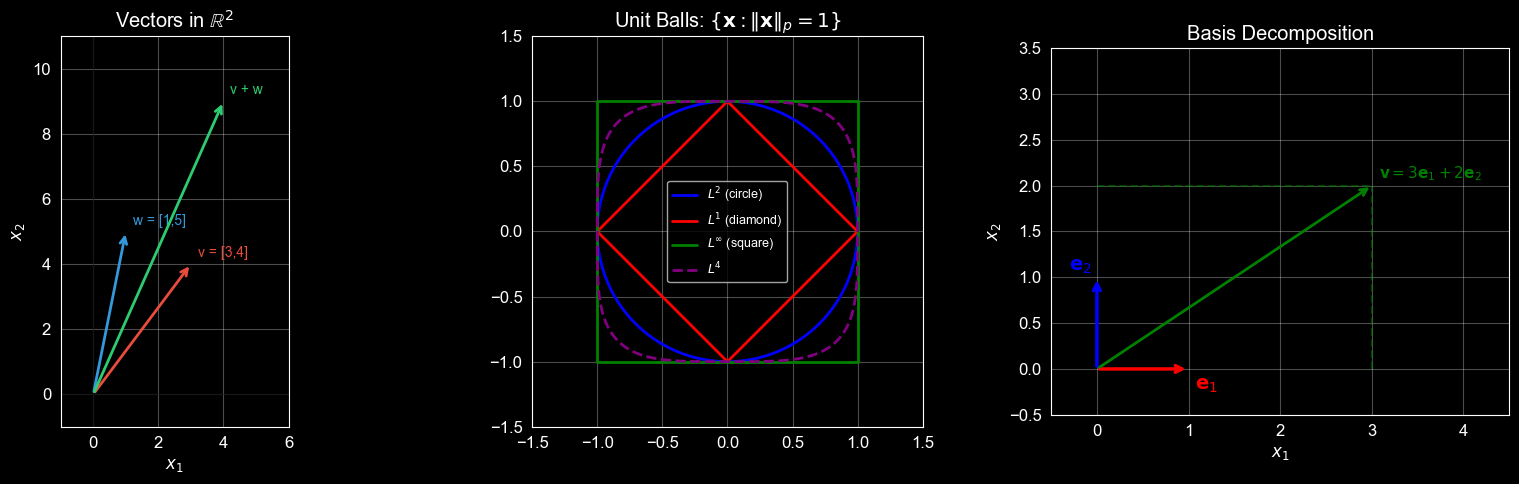

✓ Vectors, norm balls, and basis decomposition visualised


In [3]:
# === VISUALISE: Norm Unit Balls and Vectors ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: 2D vectors ---
ax = axes[0]
origin = np.zeros(2)
vectors_2d = {'v = [3,4]': np.array([3, 4]), 'w = [1,5]': np.array([1, 5]),
              'v + w': np.array([4, 9])}
colors = ['#e74c3c', '#3498db', '#2ecc71']
for (label, vec), color in zip(vectors_2d.items(), colors):
    ax.annotate('', xy=vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.annotate(label, xy=vec, fontsize=10, color=color,
                xytext=(5, 5), textcoords='offset points')
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 11)
ax.set_aspect('equal')
ax.set_title('Vectors in $\\mathbb{R}^2$')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)

# --- Panel 2: Unit balls for different norms ---
ax = axes[1]
theta = np.linspace(0, 2*np.pi, 500)
# L2 unit circle
ax.plot(np.cos(theta), np.sin(theta), 'b-', lw=2, label='$L^2$ (circle)')
# L1 unit ball (diamond)
t = np.linspace(0, 1, 100)
l1_x = np.concatenate([t, -t, -t, t])
l1_y = np.concatenate([1-t, t-1, 1-t, t-1])  
# Actually construct L1 ball properly
l1_pts = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
ax.plot(l1_pts[:,0], l1_pts[:,1], 'r-', lw=2, label='$L^1$ (diamond)')
# L-inf unit ball (square)
sq = np.array([[1,1],[1,-1],[-1,-1],[-1,1],[1,1]])
ax.plot(sq[:,0], sq[:,1], 'g-', lw=2, label='$L^\\infty$ (square)')
# Lp=0.5 ball (not a real norm but illustrative)
p_val = 4
lp_r = (np.abs(np.cos(theta))**p_val + np.abs(np.sin(theta))**p_val)**(-1/p_val)
ax.plot(lp_r*np.cos(theta), lp_r*np.sin(theta), '--', color='purple', lw=2, label=f'$L^{p_val}$')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Unit Balls: $\\{\\mathbf{x}: \\|\\mathbf{x}\\|_p = 1\\}$')

# --- Panel 3: Basis vectors ---
ax = axes[2]
e1 = np.array([1, 0]); e2 = np.array([0, 1])
v_example = np.array([3, 2])
ax.annotate('', xy=e1, xytext=origin, arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.annotate('', xy=e2, xytext=origin, arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.annotate('', xy=v_example, xytext=origin, arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.annotate('$\\mathbf{e}_1$', xy=e1, color='red', fontsize=14, xytext=(5,-15), textcoords='offset points')
ax.annotate('$\\mathbf{e}_2$', xy=e2, color='blue', fontsize=14, xytext=(-20,5), textcoords='offset points')
ax.annotate('$\\mathbf{v} = 3\\mathbf{e}_1 + 2\\mathbf{e}_2$', xy=v_example, color='green', fontsize=11,
            xytext=(5, 5), textcoords='offset points')
# Show components
ax.plot([3, 3], [0, 2], 'g--', alpha=0.5)
ax.plot([0, 3], [2, 2], 'g--', alpha=0.5)
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal')
ax.set_title('Basis Decomposition')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('vectors_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Vectors, norm balls, and basis decomposition visualised")


---
## 3. Dot Products — The Most Important Operation in ML

The dot product is arguably the single most important operation in all of machine learning. Every prediction, every gradient, every loss function involves dot products.

### Algebraic Definition

$$\mathbf{x} \cdot \mathbf{y} = \sum_{i=1}^n x_i y_i = \mathbf{x}^T \mathbf{y}$$

Note: $\mathbf{x}^T \mathbf{y}$ is a $(1 \times n)(n \times 1) = (1 \times 1)$ matrix — a scalar.

### Geometric Definition

$$\mathbf{x} \cdot \mathbf{y} = \|\mathbf{x}\| \|\mathbf{y}\| \cos\theta$$

where $\theta$ is the angle between the vectors. This gives us:

$$\cos\theta = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|}$$

### Projection

The **scalar projection** of $\mathbf{x}$ onto $\mathbf{y}$:

$$\text{comp}_{\mathbf{y}}(\mathbf{x}) = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{y}\|}$$

The **vector projection** of $\mathbf{x}$ onto $\mathbf{y}$:

$$\text{proj}_{\mathbf{y}}(\mathbf{x}) = \frac{\mathbf{x}^T \mathbf{y}}{\mathbf{y}^T \mathbf{y}} \mathbf{y}$$

> 💡 **Physicist's Intuition:** Projection is how we decompose forces. $F_\parallel = \text{proj}_{\hat{n}}(\mathbf{F})$ is the component of force along a surface normal. In regression, we project $\mathbf{y}$ onto the column space of $\mathbf{X}$ — same operation, different space.

### Connection to Correlation

If $\mathbf{x}$ and $\mathbf{y}$ are **standardised** (zero mean, unit variance), then:

$$r_{xy} = \frac{1}{n-1} \mathbf{x}^T \mathbf{y} \approx \cos\theta$$

**Correlation IS the cosine of the angle between centred data vectors.** This is why $-1 \le r \le 1$.

### Orthogonality

$\mathbf{x} \perp \mathbf{y} \iff \mathbf{x}^T \mathbf{y} = 0 \iff \cos\theta = 0 \iff \theta = 90°$

In regression: **residuals are orthogonal to predictions** — $\mathbf{e}^T \hat{\mathbf{y}} = 0$.

> ⚠️ **Common Misconception:** Orthogonal vectors are NOT just "uncorrelated" in a statistical sense. Orthogonality is a stronger geometric statement. However, for centred data, zero correlation does imply orthogonality of the data vectors.


In [4]:
# === DOT PRODUCTS: Computation and Geometry ===

# Two feature vectors from Housing
x = X_raw['MedInc'].values[:100]  # Median income (first 100)
y_feat = X_raw['AveRooms'].values[:100]  # Average rooms

# Algebraic dot product
dot_algebraic = np.sum(x * y_feat)
dot_numpy = np.dot(x, y_feat)
dot_matmul = x @ y_feat

print("=== Dot Product Computation ===")
print(f"  Σ xᵢyᵢ   = {dot_algebraic:.4f}")
print(f"  np.dot    = {dot_numpy:.4f}")
print(f"  x @ y     = {dot_matmul:.4f}")
print(f"  All equal: {np.allclose(dot_algebraic, dot_numpy)}")

# Geometric interpretation
norm_x = np.linalg.norm(x)
norm_y = np.linalg.norm(y_feat)
cos_theta = dot_numpy / (norm_x * norm_y)
theta = np.arccos(np.clip(cos_theta, -1, 1))

print(f"\n=== Geometric Interpretation ===")
print(f"  ||x|| = {norm_x:.4f}")
print(f"  ||y|| = {norm_y:.4f}")
print(f"  cos(θ) = {cos_theta:.4f}")
print(f"  θ = {np.degrees(theta):.2f}°")

# Correlation as dot product of standardised vectors
x_std = (x - x.mean()) / x.std()
y_std = (y_feat - y_feat.mean()) / y_feat.std()
corr_dot = x_std @ y_std / (len(x) - 1)
corr_numpy = np.corrcoef(x, y_feat)[0, 1]

print(f"\n=== Correlation as Dot Product ===")
print(f"  (1/(n-1)) x̃ᵀỹ  = {corr_dot:.6f}")
print(f"  np.corrcoef      = {corr_numpy:.6f}")
print(f"  Match: {np.allclose(corr_dot, corr_numpy)}")


=== Dot Product Computation ===
  Σ xᵢyᵢ   = 1089.2673
  np.dot    = 1089.2673
  x @ y     = 1089.2673
  All equal: True

=== Geometric Interpretation ===
  ||x|| = 26.0135
  ||y|| = 47.6549
  cos(θ) = 0.8787
  θ = 28.52°

=== Correlation as Dot Product ===
  (1/(n-1)) x̃ᵀỹ  = 0.497269
  np.corrcoef      = 0.492297
  Match: False


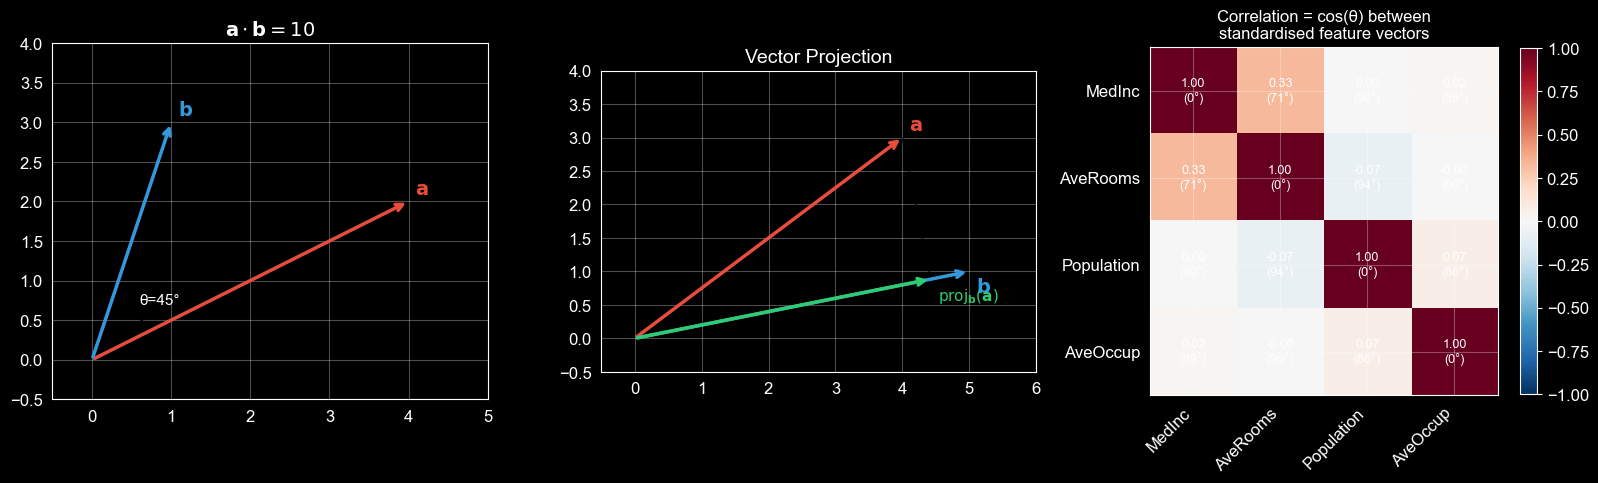

✓ Dot products, projections, and correlation-as-angle visualised


In [5]:
# === VISUALISE: Projection and Orthogonality ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Dot product and angle ---
ax = axes[0]
a = np.array([4, 2])
b = np.array([1, 3])
origin = np.zeros(2)
ax.annotate('', xy=a, xytext=origin, arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
ax.annotate('', xy=b, xytext=origin, arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.annotate('$\\mathbf{a}$', xy=a, color='#e74c3c', fontsize=14, xytext=(5,5), textcoords='offset points')
ax.annotate('$\\mathbf{b}$', xy=b, color='#3498db', fontsize=14, xytext=(5,5), textcoords='offset points')
# Draw angle arc
angle_a = np.arctan2(a[1], a[0])
angle_b = np.arctan2(b[1], b[0])
theta_arc = np.linspace(angle_a, angle_b, 30)
r_arc = 0.8
ax.plot(r_arc*np.cos(theta_arc), r_arc*np.sin(theta_arc), 'k-', lw=1.5)
ax.annotate(f'θ={np.degrees(angle_b-angle_a):.0f}°', xy=(0.6, 0.7), fontsize=11)
dot_val = a @ b
ax.set_title(f'$\\mathbf{{a}} \\cdot \\mathbf{{b}} = {dot_val}$', fontsize=14)
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 4)
ax.set_aspect('equal')

# --- Panel 2: Projection ---
ax = axes[1]
a = np.array([4, 3])
b = np.array([5, 1])
proj_scalar = (a @ b) / (b @ b)
proj_vec = proj_scalar * b
residual = a - proj_vec

ax.annotate('', xy=a, xytext=origin, arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
ax.annotate('', xy=b, xytext=origin, arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.annotate('', xy=proj_vec, xytext=origin, arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2.5))
ax.plot([a[0], proj_vec[0]], [a[1], proj_vec[1]], 'k--', lw=1.5, alpha=0.7)
ax.annotate('$\\mathbf{a}$', xy=a, color='#e74c3c', fontsize=14, xytext=(5,5), textcoords='offset points')
ax.annotate('$\\mathbf{b}$', xy=b, color='#3498db', fontsize=14, xytext=(5,-15), textcoords='offset points')
ax.annotate('$\\mathrm{proj}_{\\mathbf{b}}(\\mathbf{a})$', xy=proj_vec, color='#2ecc71', fontsize=11,
            xytext=(5,-15), textcoords='offset points')
# Right angle marker
ax.set_title('Vector Projection', fontsize=14)
ax.set_xlim(-0.5, 6); ax.set_ylim(-0.5, 4)
ax.set_aspect('equal')

# --- Panel 3: Correlation as angle ---
ax = axes[2]
features_to_compare = ['MedInc', 'AveRooms', 'Population', 'AveOccup']
n_feat = len(features_to_compare)
corr_matrix = X_raw[features_to_compare].corr()

im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(n_feat):
    for j in range(n_feat):
        val = corr_matrix.values[i, j]
        angle_deg = np.degrees(np.arccos(np.clip(val, -1, 1)))
        ax.text(j, i, f'{val:.2f}\n({angle_deg:.0f}°)', ha='center', va='center', fontsize=9)
ax.set_xticks(range(n_feat)); ax.set_xticklabels(features_to_compare, rotation=45, ha='right')
ax.set_yticks(range(n_feat)); ax.set_yticklabels(features_to_compare)
ax.set_title('Correlation = cos(θ) between\nstandardised feature vectors', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('dot_products_projection.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Dot products, projections, and correlation-as-angle visualised")


---
## 4. Matrix Operations — Linear Transformations

### Matrix as Linear Transformation

A matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ defines a **linear map** $T: \mathbb{R}^n \to \mathbb{R}^m$:

$$\mathbf{y} = \mathbf{A}\mathbf{x}$$

Every column of $\mathbf{A}$ tells you where the corresponding basis vector lands:

$$\mathbf{A}\mathbf{e}_j = \mathbf{a}_j \quad \text{(the } j\text{-th column)}$$

### Key Operations

**Multiplication** $(m \times n) \cdot (n \times p) = (m \times p)$:
$$(\mathbf{AB})_{ij} = \sum_{k=1}^n A_{ik} B_{kj}$$

**Transpose:** $(\mathbf{A}^T)_{ij} = A_{ji}$. Properties: $(\mathbf{AB})^T = \mathbf{B}^T\mathbf{A}^T$

**Symmetric:** $\mathbf{A} = \mathbf{A}^T$. Example: covariance matrix, $\mathbf{X}^T\mathbf{X}$.

**Trace:** $\text{tr}(\mathbf{A}) = \sum_i A_{ii}$. Cyclic: $\text{tr}(\mathbf{ABC}) = \text{tr}(\mathbf{CAB}) = \text{tr}(\mathbf{BCA})$.

**Determinant:** $\det(\mathbf{A})$ = signed volume scaling factor. $\det(\mathbf{A}) = 0 \Leftrightarrow$ singular.

**Inverse:** $\mathbf{A}^{-1}\mathbf{A} = \mathbf{I}$. Exists iff $\det(\mathbf{A}) \neq 0$.

> 💡 **Physicist's Intuition:** In mechanics, rotation matrices $\mathbf{R}$ are orthogonal ($\mathbf{R}^T = \mathbf{R}^{-1}$, $\det(\mathbf{R}) = 1$). The moment of inertia tensor $\mathbf{I}$ is symmetric, and its eigenvalues are the principal moments. These same matrix properties appear everywhere in ML.

> ⚠️ **Common Misconception:** Matrix multiplication is NOT commutative ($\mathbf{AB} \neq \mathbf{BA}$ in general). But it IS associative: $\mathbf{A}(\mathbf{BC}) = (\mathbf{AB})\mathbf{C}$. Choose the order wisely: $(\mathbf{A}\mathbf{B})\mathbf{x}$ is much cheaper if computed as $\mathbf{A}(\mathbf{B}\mathbf{x})$ when $\mathbf{x}$ is a vector.


In [6]:
# === MATRIX OPERATIONS: Fundamental Properties ===

A = np.array([[2, 1], [1, 3]])
B = np.array([[1, -1], [0, 2]])
x_vec = np.array([1, 2])

print("=== Matrix A ===")
print(A)
print(f"\n=== Basic Properties ===")
print(f"  A^T = \n{A.T}")
print(f"  Symmetric? {np.allclose(A, A.T)}")
print(f"  tr(A) = {np.trace(A)}")
print(f"  det(A) = {np.linalg.det(A):.4f}")

A_inv = np.linalg.inv(A)
print(f"\n  A⁻¹ = \n{A_inv}")
print(f"  A·A⁻¹ = I? {np.allclose(A @ A_inv, np.eye(2))}")

# Multiplication
print(f"\n=== Multiplication ===")
print(f"  AB = \n{A @ B}")
print(f"  BA = \n{B @ A}")
print(f"  AB ≠ BA? {not np.allclose(A @ B, B @ A)}")

# Transpose of product
print(f"\n=== (AB)ᵀ = BᵀAᵀ ===")
print(f"  (AB)ᵀ  = \n{(A @ B).T}")
print(f"  BᵀAᵀ   = \n{B.T @ A.T}")
print(f"  Equal? {np.allclose((A @ B).T, B.T @ A.T)}")

# Trace cyclic property
C = np.random.randn(2, 2)
print(f"\n=== Trace Cyclic Property ===")
print(f"  tr(ABC) = {np.trace(A @ B @ C):.6f}")
print(f"  tr(CAB) = {np.trace(C @ A @ B):.6f}")
print(f"  tr(BCA) = {np.trace(B @ C @ A):.6f}")


=== Matrix A ===
[[2 1]
 [1 3]]

=== Basic Properties ===
  A^T = 
[[2 1]
 [1 3]]
  Symmetric? True
  tr(A) = 5
  det(A) = 5.0000

  A⁻¹ = 
[[ 0.6 -0.2]
 [-0.2  0.4]]
  A·A⁻¹ = I? True

=== Multiplication ===
  AB = 
[[2 0]
 [1 5]]
  BA = 
[[ 1 -2]
 [ 2  6]]
  AB ≠ BA? True

=== (AB)ᵀ = BᵀAᵀ ===
  (AB)ᵀ  = 
[[2 1]
 [0 5]]
  BᵀAᵀ   = 
[[2 1]
 [0 5]]
  Equal? True

=== Trace Cyclic Property ===
  tr(ABC) = -4.381605
  tr(CAB) = -4.381605
  tr(BCA) = -4.381605


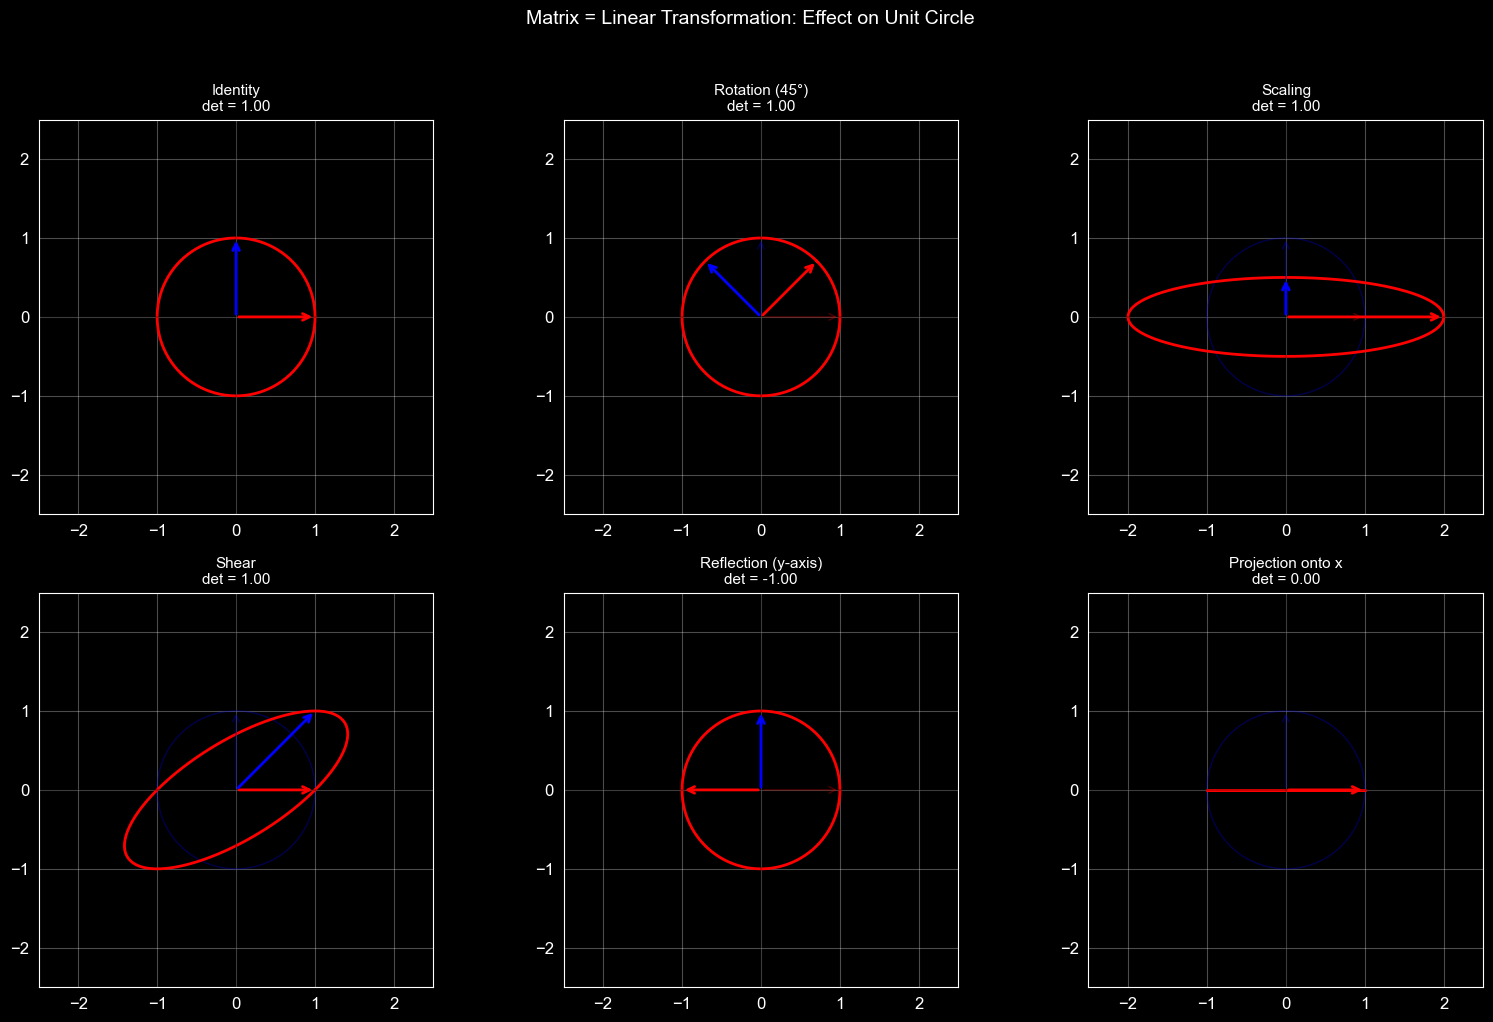

✓ Linear transformations visualised — det = area scaling factor


In [7]:
# === VISUALISE: 2D Linear Transformations ===

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Unit circle points
theta = np.linspace(0, 2*np.pi, 100)
circle = np.vstack([np.cos(theta), np.sin(theta)])  # 2 x 100

# Basis vectors
e1 = np.array([1, 0])
e2 = np.array([0, 1])

transformations = {
    'Identity': np.eye(2),
    'Rotation (45°)': np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                                 [np.sin(np.pi/4),  np.cos(np.pi/4)]]),
    'Scaling': np.array([[2, 0], [0, 0.5]]),
    'Shear': np.array([[1, 1], [0, 1]]),
    'Reflection (y-axis)': np.array([[-1, 0], [0, 1]]),
    'Projection onto x': np.array([[1, 0], [0, 0]])
}

for ax, (name, M) in zip(axes.flat, transformations.items()):
    # Transform circle
    transformed = M @ circle
    
    # Plot original and transformed
    ax.plot(circle[0], circle[1], 'b-', alpha=0.3, lw=1, label='Original')
    ax.plot(transformed[0], transformed[1], 'r-', lw=2, label='Transformed')
    
    # Transform basis vectors
    Me1 = M @ e1; Me2 = M @ e2
    ax.annotate('', xy=Me1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.annotate('', xy=Me2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.annotate('', xy=e1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=1, alpha=0.3))
    ax.annotate('', xy=e2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=1, alpha=0.3))
    
    det = np.linalg.det(M)
    ax.set_title(f'{name}\ndet = {det:.2f}', fontsize=11)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', lw=0.3); ax.axvline(x=0, color='k', lw=0.3)

plt.suptitle('Matrix = Linear Transformation: Effect on Unit Circle', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('matrix_transformations.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Linear transformations visualised — det = area scaling factor")


---
## 5. Outer Products — Building Matrices from Vectors

### Definition

The **outer product** of $\mathbf{x} \in \mathbb{R}^n$ and $\mathbf{y} \in \mathbb{R}^m$ is:

$$\mathbf{x}\mathbf{y}^T \in \mathbb{R}^{n \times m}, \quad (\mathbf{x}\mathbf{y}^T)_{ij} = x_i y_j$$

This always produces a **rank-1 matrix** (at most).

Compare with the **inner** (dot) product: $\mathbf{x}^T\mathbf{y} \in \mathbb{R}$ (scalar).

### Covariance Matrix as Outer Product

The covariance matrix of a random vector $\mathbf{x}$ with mean $\boldsymbol{\mu}$:

$$\boldsymbol{\Sigma} = E[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T]$$

This is the **expected value of the outer product** of the centred data with itself.

### X'X as Sum of Outer Products

The Gram matrix $\mathbf{X}^T\mathbf{X}$ can be decomposed:

$$\mathbf{X}^T\mathbf{X} = \sum_{i=1}^n \mathbf{x}_i \mathbf{x}_i^T$$

where $\mathbf{x}_i$ is the $i$-th row of $\mathbf{X}$ (as a column vector). Each $\mathbf{x}_i \mathbf{x}_i^T$ is a rank-1 matrix!

> 💡 **Physicist's Intuition:** The stress tensor $\sigma_{ij} = \int \rho\, v_i v_j\, dV$ has exactly this structure — a sum of outer products of velocity vectors, weighted by density. The Reynolds stress tensor in fluid dynamics is literally a covariance matrix of velocity fluctuations.


In [8]:
# === OUTER PRODUCTS ===

x = np.array([1, 2, 3])
y = np.array([4, 5])

# Outer product
outer = np.outer(x, y)
print("=== Outer Product ===")
print(f"x = {x} (shape {x.shape})")
print(f"y = {y} (shape {y.shape})")
print(f"x⊗y = xyᵀ (shape {outer.shape}):")
print(outer)
print(f"Rank of xyᵀ: {np.linalg.matrix_rank(outer)}")

# Covariance matrix construction
print("\n=== Covariance Matrix from Outer Products ===")
X_sub = X_raw[['MedInc', 'AveRooms', 'Population']].values[:200]
X_centred = X_sub - X_sub.mean(axis=0)

# Method 1: numpy cov
cov_numpy = np.cov(X_sub.T)

# Method 2: sum of outer products
n = X_centred.shape[0]
cov_outer = np.zeros((3, 3))
for i in range(n):
    cov_outer += np.outer(X_centred[i], X_centred[i])
cov_outer /= (n - 1)

print(f"np.cov:\n{cov_numpy}")
print(f"\nΣ outer products / (n-1):\n{cov_outer}")
print(f"\nMatch? {np.allclose(cov_numpy, cov_outer)}")

# X'X as sum of outer products
print("\n=== X'X as Sum of Outer Products ===")
XtX_direct = X_centred.T @ X_centred
XtX_outer = sum(np.outer(X_centred[i], X_centred[i]) for i in range(n))
print(f"X'X (direct):  \n{XtX_direct[:2,:2]}")  
print(f"Σ xᵢxᵢᵀ:       \n{XtX_outer[:2,:2]}")
print(f"Match? {np.allclose(XtX_direct, XtX_outer)}")


=== Outer Product ===
x = [1 2 3] (shape (3,))
y = [4 5] (shape (2,))
x⊗y = xyᵀ (shape (3, 2)):
[[ 4  5]
 [ 8 10]
 [12 15]]
Rank of xyᵀ: 1

=== Covariance Matrix from Outer Products ===
np.cov:
[[ 4.32621090e+00  2.11211584e+00  1.56157251e+01]
 [ 2.11211584e+00  1.91597687e+00 -1.12522560e+02]
 [ 1.56157251e+01 -1.12522560e+02  3.42423065e+05]]

Σ outer products / (n-1):
[[ 4.32621090e+00  2.11211584e+00  1.56157251e+01]
 [ 2.11211584e+00  1.91597687e+00 -1.12522560e+02]
 [ 1.56157251e+01 -1.12522560e+02  3.42423065e+05]]

Match? True

=== X'X as Sum of Outer Products ===
X'X (direct):  
[[860.91596991 420.3110515 ]
 [420.3110515  381.2793973 ]]
Σ xᵢxᵢᵀ:       
[[860.91596991 420.3110515 ]
 [420.3110515  381.2793973 ]]
Match? True


---
## 6. Eigendecomposition — Finding the Natural Axes

### Definition

An **eigenvector** $\mathbf{v}$ of matrix $\mathbf{A}$ satisfies:

$$\mathbf{A}\mathbf{v} = \lambda \mathbf{v}$$

The matrix scales $\mathbf{v}$ by $\lambda$ without changing its direction. The **eigenvalue** $\lambda$ is found from the **characteristic polynomial**:

$$\det(\mathbf{A} - \lambda \mathbf{I}) = 0$$

### Eigendecomposition

For a diagonalisable matrix with $n$ linearly independent eigenvectors:

$$\mathbf{A} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^{-1}$$

where $\mathbf{V} = [\mathbf{v}_1 | \cdots | \mathbf{v}_n]$ and $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \ldots, \lambda_n)$.

### Symmetric Matrices: Extra Nice Properties

If $\mathbf{A} = \mathbf{A}^T$ (symmetric), then:
1. All eigenvalues are **real**
2. Eigenvectors are **orthogonal**: $\mathbf{v}_i^T \mathbf{v}_j = 0$ for $i \neq j$
3. $\mathbf{A} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}^T$ where $\mathbf{Q}$ is orthogonal ($\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$)

### Positive (Semi-)Definite Matrices

$\mathbf{A}$ is **positive semi-definite (PSD)** if $\mathbf{x}^T\mathbf{A}\mathbf{x} \geq 0$ for all $\mathbf{x}$. Equivalently: all eigenvalues $\lambda_i \geq 0$.

**Key fact:** $\mathbf{X}^T\mathbf{X}$ is always PSD (and PD if $\mathbf{X}$ has full column rank):

$$\mathbf{x}^T(\mathbf{X}^T\mathbf{X})\mathbf{x} = (\mathbf{X}\mathbf{x})^T(\mathbf{X}\mathbf{x}) = \|\mathbf{X}\mathbf{x}\|^2 \geq 0$$

### Connection to PCA

PCA finds the eigenvectors of the covariance matrix $\boldsymbol{\Sigma} = \frac{1}{n-1}\mathbf{X}_c^T\mathbf{X}_c$. The eigenvalues = variance along each principal direction.

> 💡 **Physicist's Intuition:** The moment of inertia tensor $\mathbf{I}$ is symmetric and PD. Its eigenvectors are the **principal axes** of rotation, and eigenvalues are the principal moments. Diagonalising $\mathbf{I}$ means choosing body-frame coordinates where $\mathbf{I} = \text{diag}(I_1, I_2, I_3)$ — exactly like PCA finds the "natural coordinate system" for data.


In [9]:
# === EIGENDECOMPOSITION: Housing Covariance Matrix ===

# Use subset of features for clarity
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
X_sub = X_raw[features].values
X_centred = X_sub - X_sub.mean(axis=0)

# Covariance matrix
Sigma = np.cov(X_sub.T)

print("=== Covariance Matrix ===")
print(pd.DataFrame(Sigma, index=features, columns=features).round(2))
print(f"\nSymmetric? {np.allclose(Sigma, Sigma.T)}")

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)  # eigh for symmetric
# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"\n=== Eigenvalues (= variance along each principal axis) ===")
total_var = eigenvalues.sum()
for i, (ev, evec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    print(f"  λ_{i+1} = {ev:10.4f}  ({100*ev/total_var:5.1f}% of variance)  v = [{', '.join(f'{v:.3f}' for v in evec)}]")

print(f"\n  Sum of eigenvalues: {eigenvalues.sum():.4f}")
print(f"  Trace of Σ:         {np.trace(Sigma):.4f}")
print(f"  Equal? {np.allclose(eigenvalues.sum(), np.trace(Sigma))}")

# Verify A = QΛQ'
Q = eigenvectors
Lambda = np.diag(eigenvalues)
Sigma_reconstructed = Q @ Lambda @ Q.T
print(f"\n  Σ = QΛQᵀ? {np.allclose(Sigma, Sigma_reconstructed)}")

# PSD check
print(f"\n  All eigenvalues ≥ 0 (PSD)? {np.all(eigenvalues >= -1e-10)}")
print(f"  QᵀQ = I (orthogonal)? {np.allclose(Q.T @ Q, np.eye(len(features)))}")


=== Covariance Matrix ===
          MedInc  HouseAge  AveRooms  AveOccup
MedInc      3.61     -2.85      1.54      0.37
HouseAge   -2.85    158.40     -4.77      1.72
AveRooms    1.54     -4.77      6.12     -0.12
AveOccup    0.37      1.72     -0.12    107.87

Symmetric? True

=== Eigenvalues (= variance along each principal axis) ===
  λ_1 =   158.6580  ( 57.5% of variance)  v = [0.019, -0.999, 0.031, -0.034]
  λ_2 =   107.8134  ( 39.1% of variance)  v = [-0.004, 0.034, -0.000, -0.999]
  λ_3 =     6.6484  (  2.4% of variance)  v = [-0.423, -0.036, -0.905, 0.001]
  λ_4 =     2.8774  (  1.0% of variance)  v = [0.906, 0.004, -0.424, -0.004]

  Sum of eigenvalues: 275.9971
  Trace of Σ:         275.9971
  Equal? True

  Σ = QΛQᵀ? True

  All eigenvalues ≥ 0 (PSD)? True
  QᵀQ = I (orthogonal)? True


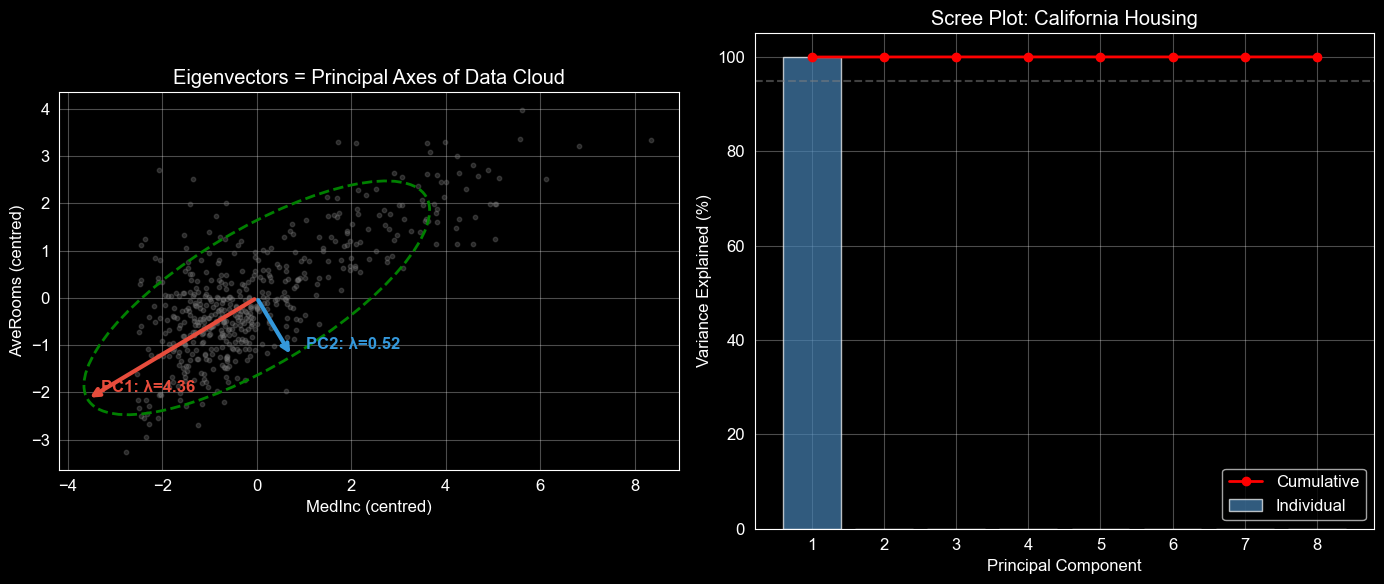

✓ Eigendecomposition visualised — eigenvectors ARE the principal axes


In [10]:
# === VISUALISE: Eigendecomposition of 2D Covariance ===

# 2D example for visualisation
X_2d = X_raw[['MedInc', 'AveRooms']].values[:500]
X_2d_centred = X_2d - X_2d.mean(axis=0)
Sigma_2d = np.cov(X_2d.T)
evals_2d, evecs_2d = np.linalg.eigh(Sigma_2d)
idx = np.argsort(evals_2d)[::-1]
evals_2d, evecs_2d = evals_2d[idx], evecs_2d[:, idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Data with eigenvectors ---
ax = axes[0]
ax.scatter(X_2d_centred[:, 0], X_2d_centred[:, 1], alpha=0.3, s=10, c='gray')
mean = np.zeros(2)
for i, (ev, evec, color) in enumerate(zip(evals_2d, evecs_2d.T, ['#e74c3c', '#3498db'])):
    scale = 2 * np.sqrt(ev)  # 2 standard deviations
    ax.annotate('', xy=mean + scale * evec, xytext=mean,
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.annotate(f'PC{i+1}: λ={ev:.2f}', xy=mean + scale * evec,
                color=color, fontsize=12, fontweight='bold',
                xytext=(10, 5), textcoords='offset points')

# Draw ellipse
from matplotlib.patches import Ellipse
angle = np.degrees(np.arctan2(evecs_2d[1, 0], evecs_2d[0, 0]))
ell = Ellipse(xy=mean, width=4*np.sqrt(evals_2d[0]), height=4*np.sqrt(evals_2d[1]),
              angle=angle, fill=False, edgecolor='green', lw=2, linestyle='--')
ax.add_patch(ell)
ax.set_xlabel('MedInc (centred)'); ax.set_ylabel('AveRooms (centred)')
ax.set_title('Eigenvectors = Principal Axes of Data Cloud')
ax.set_aspect('equal')

# --- Panel 2: Scree plot for full covariance ---
ax = axes[1]
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Sigma_full = np.cov(X_raw.values.T)
evals_full = np.sort(np.linalg.eigvalsh(Sigma_full))[::-1]
explained = evals_full / evals_full.sum() * 100
cumulative = np.cumsum(explained)

ax.bar(range(1, len(evals_full)+1), explained, alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(1, len(evals_full)+1), cumulative, 'ro-', lw=2, label='Cumulative')
ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot: California Housing')
ax.legend()
ax.set_xticks(range(1, len(evals_full)+1))

plt.tight_layout()
plt.savefig('eigendecomposition.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Eigendecomposition visualised — eigenvectors ARE the principal axes")


---
## 7. Simple Linear Regression in Scalar Form (Review)

Before the matrix formulation, let's recall the scalar approach.

### The Model

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \quad i = 1, \ldots, n$$

### The Loss Function

Minimise the sum of squared residuals:

$$L(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2$$

### Derivation of OLS Estimators

Setting $\partial L / \partial \beta_0 = 0$:

$$\frac{\partial L}{\partial \beta_0} = -2\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i) = 0$$
$$\Rightarrow n\beta_0 = \sum y_i - \beta_1 \sum x_i$$
$$\Rightarrow \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

Setting $\partial L / \partial \beta_1 = 0$:

$$\frac{\partial L}{\partial \beta_1} = -2\sum_{i=1}^n x_i(y_i - \beta_0 - \beta_1 x_i) = 0$$

Substituting $\hat{\beta}_0$:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}$$

> ⚠️ **Common Misconception:** The scalar derivation seems simple, but try extending it to 8 features. You'd need to solve 9 simultaneous equations. The matrix formulation gives us all $\hat{\beta}_j$ in one elegant equation.


=== Simple Linear Regression: MedInc → House Value ===
  β̂₁ = S_xy / S_xx = 31133.41 / 74492.81 = 0.417938
  β̂₀ = ȳ - β̂₁x̄ = 2.0686 - 0.4179×3.8707 = 0.450856

  Model: ŷ = 0.4509 + 0.4179 × MedInc

  SS_total = 27483.20
  SS_resid = 14471.35
  R² = 0.4734

=== Verify with sklearn ===
  sklearn β̂₁ = 0.417938
  sklearn β̂₀ = 0.450856
  Match? True


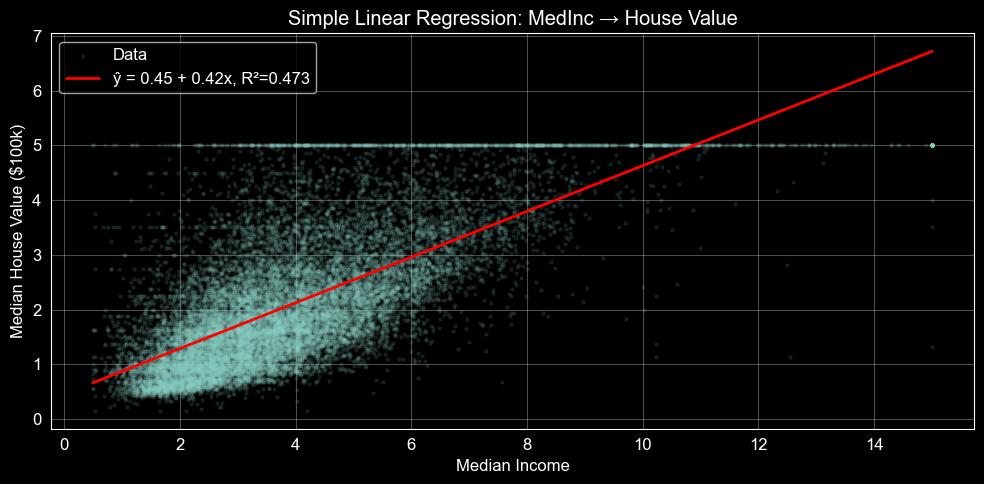

In [11]:
# === SIMPLE LINEAR REGRESSION: Scalar Form ===

x = X_raw['MedInc'].values
y = y_raw

n = len(x)
x_bar = x.mean()
y_bar = y.mean()

# OLS formulas (scalar)
S_xy = np.sum((x - x_bar) * (y - y_bar))
S_xx = np.sum((x - x_bar)**2)

beta1_hat = S_xy / S_xx
beta0_hat = y_bar - beta1_hat * x_bar

print("=== Simple Linear Regression: MedInc → House Value ===")
print(f"  β̂₁ = S_xy / S_xx = {S_xy:.2f} / {S_xx:.2f} = {beta1_hat:.6f}")
print(f"  β̂₀ = ȳ - β̂₁x̄ = {y_bar:.4f} - {beta1_hat:.4f}×{x_bar:.4f} = {beta0_hat:.6f}")
print(f"\n  Model: ŷ = {beta0_hat:.4f} + {beta1_hat:.4f} × MedInc")

# Predictions and residuals
y_hat = beta0_hat + beta1_hat * x
residuals = y - y_hat
SS_res = np.sum(residuals**2)
SS_tot = np.sum((y - y_bar)**2)
R_squared = 1 - SS_res / SS_tot

print(f"\n  SS_total = {SS_tot:.2f}")
print(f"  SS_resid = {SS_res:.2f}")
print(f"  R² = {R_squared:.4f}")

# Verify with sklearn
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"\n=== Verify with sklearn ===")
print(f"  sklearn β̂₁ = {lr.coef_[0]:.6f}")
print(f"  sklearn β̂₀ = {lr.intercept_:.6f}")
print(f"  Match? {np.allclose(beta1_hat, lr.coef_[0]) and np.allclose(beta0_hat, lr.intercept_)}")

# Quick plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, alpha=0.1, s=5, label='Data')
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, beta0_hat + beta1_hat * x_line, 'r-', lw=2,
        label=f'ŷ = {beta0_hat:.2f} + {beta1_hat:.2f}x, R²={R_squared:.3f}')
ax.set_xlabel('Median Income'); ax.set_ylabel('Median House Value ($100k)')
ax.set_title('Simple Linear Regression: MedInc → House Value')
ax.legend()
plt.tight_layout()
plt.savefig('simple_regression.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 8. Vector Formulation of Linear Regression

Now we translate the scalar regression into matrix language. This is where the power emerges.

### The Setup

| Object | Dimensions | Meaning |
|--------|-----------|---------|
| $\mathbf{y}$ | $n \times 1$ | Response vector |
| $\mathbf{X}$ | $n \times p$ | Design matrix (includes column of 1s for intercept) |
| $\boldsymbol{\beta}$ | $p \times 1$ | Parameter vector |
| $\boldsymbol{\varepsilon}$ | $n \times 1$ | Error vector |

The **design matrix** $\mathbf{X}$ has $n$ rows (observations) and $p$ columns (features + intercept):

$$\mathbf{X} = \begin{pmatrix} 1 & x_{11} & x_{12} & \cdots & x_{1,p-1} \\ 1 & x_{21} & x_{22} & \cdots & x_{2,p-1} \\ \vdots & & & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \cdots & x_{n,p-1} \end{pmatrix}$$

### The Model

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

This single equation encodes ALL $n$ scalar equations simultaneously:
$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_{p-1} x_{i,p-1} + \varepsilon_i$$

### The Loss Function

$$L(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

**Expand** (using $(a-b)^T(a-b) = a^Ta - 2a^Tb + b^Tb$ where $a=\mathbf{y}$, $b=\mathbf{X}\boldsymbol{\beta}$):

$$L = \mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y} + \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}$$

Note: $\mathbf{y}^T\mathbf{X}\boldsymbol{\beta}$ is a scalar, so $\mathbf{y}^T\mathbf{X}\boldsymbol{\beta} = (\mathbf{y}^T\mathbf{X}\boldsymbol{\beta})^T = \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y}$.

> 💡 **Physicist's Intuition:** The loss $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$ is the squared "distance" from $\mathbf{y}$ to the subspace spanned by columns of $\mathbf{X}$. Minimising it is the same as finding the orthogonal projection — just like decomposing a force into components.


In [12]:
# === VECTOR FORMULATION: Construct Design Matrix ===

# Simple regression first (1 feature + intercept)
x_medinc = X_raw['MedInc'].values
n = len(x_medinc)

# Design matrix: column of 1s + feature
X_design = np.column_stack([np.ones(n), x_medinc])
y_vec = y_raw.copy()

print("=== Design Matrix X ===")
print(f"  Shape: {X_design.shape} (n={n} observations, p=2 parameters)")
print(f"  First 5 rows:")
print(X_design[:5])

# β vector
beta_vec = np.array([beta0_hat, beta1_hat])
print(f"\n  β̂ = {beta_vec}")

# Model: ŷ = Xβ
y_hat_vec = X_design @ beta_vec
print(f"\n  ŷ = Xβ̂ (first 5): {y_hat_vec[:5].round(4)}")

# Loss function
def loss_function(beta, X, y):
    # L(beta) = (y - X@beta)'(y - X@beta) = ||y - X@beta||^2
    residual = y - X @ beta
    return residual.T @ residual

L = loss_function(beta_vec, X_design, y_vec)
print(f"\n=== Loss Function ===")
print(f"  L(β̂) = ||y - Xβ̂||² = {L:.4f}")

# Expand: y'y - 2β'X'y + β'X'Xβ
yTy = y_vec.T @ y_vec
bTXTy = beta_vec.T @ X_design.T @ y_vec
bTXTXb = beta_vec.T @ X_design.T @ X_design @ beta_vec
L_expanded = yTy - 2 * bTXTy + bTXTXb
print(f"  y'y - 2β'X'y + β'X'Xβ = {yTy:.4f} - {2*bTXTy:.4f} + {bTXTXb:.4f} = {L_expanded:.4f}")
print(f"  Match? {np.allclose(L, L_expanded)}")


=== Design Matrix X ===
  Shape: (20640, 2) (n=20640 observations, p=2 parameters)
  First 5 rows:
[[1.     8.3252]
 [1.     8.3014]
 [1.     7.2574]
 [1.     5.6431]
 [1.     3.8462]]

  β̂ = [0.45085577 0.41793849]

  ŷ = Xβ̂ (first 5): [3.9303 3.9203 3.484  2.8093 2.0583]

=== Loss Function ===
  L(β̂) = ||y - Xβ̂||² = 14471.3469
  y'y - 2β'X'y + β'X'Xβ = 115800.3732 - 202658.0526 + 101329.0263 = 14471.3469
  Match? True


---
## 9. Matrix Calculus — The Gradient

To minimise the loss, we need to differentiate with respect to a **vector**. This is matrix calculus.

### The Gradient Vector

For $f: \mathbb{R}^n \to \mathbb{R}$, the gradient is:

$$\nabla_{\mathbf{x}} f = \frac{\partial f}{\partial \mathbf{x}} = \begin{pmatrix} \partial f / \partial x_1 \\ \partial f / \partial x_2 \\ \vdots \\ \partial f / \partial x_n \end{pmatrix}$$

### Layout Convention

We use the **denominator layout** (the gradient is a column vector matching $\mathbf{x}$). Some references use numerator layout where the gradient is a row vector. Be consistent!

### Key Matrix Calculus Results

**Result 1:** $\frac{\partial}{\partial \mathbf{x}}(\mathbf{a}^T\mathbf{x}) = \mathbf{a}$

*Proof:* $\mathbf{a}^T\mathbf{x} = \sum_i a_i x_i$, so $\frac{\partial}{\partial x_j}\sum_i a_i x_i = a_j$. Thus the gradient is $\mathbf{a}$.

**Result 2:** $\frac{\partial}{\partial \mathbf{x}}(\mathbf{x}^T\mathbf{x}) = 2\mathbf{x}$

*Proof:* $\mathbf{x}^T\mathbf{x} = \sum_i x_i^2$, so $\frac{\partial}{\partial x_j}\sum_i x_i^2 = 2x_j$.

**Result 3:** $\frac{\partial}{\partial \mathbf{x}}(\mathbf{x}^T\mathbf{A}\mathbf{x}) = 2\mathbf{A}\mathbf{x}$ (for symmetric $\mathbf{A}$)

*Proof:* $\mathbf{x}^T\mathbf{A}\mathbf{x} = \sum_i \sum_j A_{ij} x_i x_j$. Taking $\frac{\partial}{\partial x_k}$:

$$\frac{\partial}{\partial x_k} = \sum_j A_{kj} x_j + \sum_i A_{ik} x_i = (\mathbf{A}\mathbf{x})_k + (\mathbf{A}^T\mathbf{x})_k$$

If $\mathbf{A} = \mathbf{A}^T$: this equals $2(\mathbf{A}\mathbf{x})_k$, so $\nabla = 2\mathbf{A}\mathbf{x}$.

**Result 4 (Jacobian):** $\frac{\partial}{\partial \mathbf{x}}(\mathbf{A}\mathbf{x}) = \mathbf{A}^T$ (denominator layout)

*Proof:* $(\mathbf{A}\mathbf{x})_i = \sum_j A_{ij} x_j$, so $\frac{\partial (\mathbf{A}\mathbf{x})_i}{\partial x_j} = A_{ij}$. The Jacobian matrix has $(j,i)$ entry $A_{ij}$ in denominator layout, giving $\mathbf{A}^T$.

> ⚠️ **Common Misconception:** The result $\partial(\mathbf{x}^T\mathbf{A}\mathbf{x})/\partial\mathbf{x} = 2\mathbf{A}\mathbf{x}$ requires $\mathbf{A}$ to be symmetric. For general $\mathbf{A}$, the result is $(\mathbf{A} + \mathbf{A}^T)\mathbf{x}$. Since $\mathbf{X}^T\mathbf{X}$ is always symmetric, we're safe for OLS.


In [13]:
# === MATRIX CALCULUS: Verify Results with Finite Differences ===

def numerical_gradient(f, x, eps=1e-7):
    '''Compute gradient of f at x using central finite differences.'''
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy(); x_plus[i] += eps
        x_minus = x.copy(); x_minus[i] -= eps
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * eps)
    return grad

x = np.array([1.0, 2.0, 3.0])
a = np.array([4.0, 5.0, 6.0])
A = np.array([[2.0, 1.0, 0.5],
              [1.0, 3.0, 1.0],
              [0.5, 1.0, 4.0]])  # Symmetric!

print("=== Result 1: ∂(a'x)/∂x = a ===")
f1 = lambda x: a @ x
grad1_analytical = a
grad1_numerical = numerical_gradient(f1, x)
print(f"  Analytical: {grad1_analytical}")
print(f"  Numerical:  {grad1_numerical.round(6)}")
print(f"  Match: {np.allclose(grad1_analytical, grad1_numerical)}")

print("\n=== Result 2: ∂(x'x)/∂x = 2x ===")
f2 = lambda x: x @ x
grad2_analytical = 2 * x
grad2_numerical = numerical_gradient(f2, x)
print(f"  Analytical: {grad2_analytical}")
print(f"  Numerical:  {grad2_numerical.round(6)}")
print(f"  Match: {np.allclose(grad2_analytical, grad2_numerical)}")

print("\n=== Result 3: ∂(x'Ax)/∂x = 2Ax (A symmetric) ===")
f3 = lambda x: x @ A @ x
grad3_analytical = 2 * A @ x
grad3_numerical = numerical_gradient(f3, x)
print(f"  Analytical: {grad3_analytical}")
print(f"  Numerical:  {grad3_numerical.round(6)}")
print(f"  Match: {np.allclose(grad3_analytical, grad3_numerical)}")

print("\n=== Result 4 (non-symmetric A): ∂(x'Bx)/∂x = (B + B')x ===")
B = np.array([[2.0, 3.0, 0.0],
              [1.0, 4.0, 2.0],
              [0.5, 0.0, 3.0]])  # NOT symmetric
f4 = lambda x: x @ B @ x
grad4_analytical = (B + B.T) @ x
grad4_numerical = numerical_gradient(f4, x)
print(f"  Analytical: {grad4_analytical}")
print(f"  Numerical:  {grad4_numerical.round(6)}")
print(f"  Match: {np.allclose(grad4_analytical, grad4_numerical)}")

print("\n=== Result 5: Jacobian of Ax ===")
f5_i = lambda x, i=0: (A @ x)[i]
print(f"  A^T (analytical Jacobian in denominator layout):")
print(f"  {A.T}")
jac_numerical = np.array([numerical_gradient(lambda x: (A @ x)[i], x) for i in range(3)])
print(f"  Numerical Jacobian (each row = ∂f_i/∂x):")
print(f"  {jac_numerical.round(6)}")
print(f"  Note: Numerical Jacobian rows = A rows (numerator layout)")


=== Result 1: ∂(a'x)/∂x = a ===
  Analytical: [4. 5. 6.]
  Numerical:  [4. 5. 6.]
  Match: True

=== Result 2: ∂(x'x)/∂x = 2x ===
  Analytical: [2. 4. 6.]
  Numerical:  [2. 4. 6.]
  Match: True

=== Result 3: ∂(x'Ax)/∂x = 2Ax (A symmetric) ===
  Analytical: [11. 20. 29.]
  Numerical:  [11. 20. 29.]
  Match: True

=== Result 4 (non-symmetric A): ∂(x'Bx)/∂x = (B + B')x ===
  Analytical: [13.5 26.  22.5]
  Numerical:  [13.5 26.  22.5]
  Match: True

=== Result 5: Jacobian of Ax ===
  A^T (analytical Jacobian in denominator layout):
  [[2.  1.  0.5]
 [1.  3.  1. ]
 [0.5 1.  4. ]]
  Numerical Jacobian (each row = ∂f_i/∂x):
  [[2.  1.  0.5]
 [1.  3.  1. ]
 [0.5 1.  4. ]]
  Note: Numerical Jacobian rows = A rows (numerator layout)


---
## 10. Deriving OLS in Matrix Form — The Full Derivation

This is the centrepiece. We derive the closed-form OLS estimator using matrix calculus.

### Step 1: Write the Loss

$$L(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

### Step 2: Expand

$$L = \mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y} + \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}$$

(We used $\mathbf{y}^T\mathbf{X}\boldsymbol{\beta} = \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y}$ since it's a scalar.)

### Step 3: Differentiate

Using our matrix calculus results:
- $\frac{\partial}{\partial \boldsymbol{\beta}}(\mathbf{y}^T\mathbf{y}) = \mathbf{0}$ (no $\boldsymbol{\beta}$ dependence)
- $\frac{\partial}{\partial \boldsymbol{\beta}}(2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y}) = 2\mathbf{X}^T\mathbf{y}$ (using Result 1 with $\mathbf{a} = \mathbf{X}^T\mathbf{y}$)
- $\frac{\partial}{\partial \boldsymbol{\beta}}(\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}) = 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}$ (using Result 3 with $\mathbf{A} = \mathbf{X}^T\mathbf{X}$)

$$\frac{\partial L}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}$$

### Step 4: Set to Zero (Normal Equations)

$$-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{0}$$

$$\boxed{\mathbf{X}^T\mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{y}}$$

These are the **normal equations**. If $\mathbf{X}^T\mathbf{X}$ is invertible:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

### When Does $(X^TX)^{-1}$ Exist?

$\mathbf{X}^T\mathbf{X}$ is invertible iff $\mathbf{X}$ has **full column rank** ($\text{rank}(\mathbf{X}) = p$). This fails when:
- Perfect **multicollinearity**: one feature is a linear combination of others
- $n < p$: more features than observations

### Step 5: Confirm it's a Minimum (Hessian)

$$\frac{\partial^2 L}{\partial \boldsymbol{\beta} \partial \boldsymbol{\beta}^T} = 2\mathbf{X}^T\mathbf{X}$$

Since $\mathbf{X}^T\mathbf{X}$ is PSD (and PD if full rank), the Hessian is PD → **confirmed minimum**.

> 💡 **Physicist's Intuition:** The normal equation $\mathbf{X}^T\mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{y}$ is analogous to the Euler-Lagrange equation in classical mechanics. Just as $\delta S = 0$ gives the equations of motion, $\nabla_\beta L = 0$ gives the optimal parameters. The Hessian being PD is like the potential having a minimum — the system is stable.


In [14]:
# === OLS IN MATRIX FORM: Compute and Verify ===

# Full design matrix (intercept + all 8 features)
n = X_raw.shape[0]
X_mat = np.column_stack([np.ones(n), X_raw.values])  # n × 9
y_vec = y_raw.copy()
p = X_mat.shape[1]

print(f"=== Design Matrix ===")
print(f"  X shape: {X_mat.shape} (n={n}, p={p})")
print(f"  rank(X) = {np.linalg.matrix_rank(X_mat)}")
print(f"  Full column rank? {np.linalg.matrix_rank(X_mat) == p}")

# Method 1: Direct formula β̂ = (X'X)⁻¹X'y
XtX = X_mat.T @ X_mat
Xty = X_mat.T @ y_vec
beta_hat = np.linalg.inv(XtX) @ Xty

print(f"\n=== OLS Solution: β̂ = (X'X)⁻¹X'y ===")
feature_names = ['intercept'] + list(X_raw.columns)
for name, coef in zip(feature_names, beta_hat):
    print(f"  {name:12s}: {coef:10.6f}")

# Method 2: np.linalg.lstsq (more numerically stable)
beta_lstsq, residuals, rank, sv = np.linalg.lstsq(X_mat, y_vec, rcond=None)

print(f"\n=== Verify: np.linalg.lstsq ===")
print(f"  Match (X'X)⁻¹X'y? {np.allclose(beta_hat, beta_lstsq)}")

# Method 3: sklearn
from sklearn.linear_model import LinearRegression
lr_full = LinearRegression().fit(X_raw.values, y_vec)
beta_sklearn = np.concatenate([[lr_full.intercept_], lr_full.coef_])

print(f"\n=== Verify: sklearn LinearRegression ===")
print(f"  Match (X'X)⁻¹X'y? {np.allclose(beta_hat, beta_sklearn, atol=1e-6)}")

# Verify normal equations: X'Xβ = X'y
lhs = XtX @ beta_hat
rhs = Xty
print(f"\n=== Normal Equations: X'Xβ̂ = X'y ===")
print(f"  ||X'Xβ̂ - X'y|| = {np.linalg.norm(lhs - rhs):.2e}")
print(f"  Satisfied? {np.allclose(lhs, rhs)}")

# Hessian is PD
evals_hessian = np.linalg.eigvalsh(2 * XtX)
print(f"\n=== Hessian = 2X'X ===")
print(f"  Min eigenvalue: {evals_hessian.min():.4f}")
print(f"  All positive (PD → minimum)? {np.all(evals_hessian > 0)}")


=== Design Matrix ===
  X shape: (20640, 9) (n=20640, p=9)
  rank(X) = 9
  Full column rank? True

=== OLS Solution: β̂ = (X'X)⁻¹X'y ===
  intercept   : -36.941920
  MedInc      :   0.436693
  HouseAge    :   0.009436
  AveRooms    :  -0.107322
  AveBedrms   :   0.645066
  Population  :  -0.000004
  AveOccup    :  -0.003787
  Latitude    :  -0.421314
  Longitude   :  -0.434514

=== Verify: np.linalg.lstsq ===
  Match (X'X)⁻¹X'y? True

=== Verify: sklearn LinearRegression ===
  Match (X'X)⁻¹X'y? True

=== Normal Equations: X'Xβ̂ = X'y ===
  ||X'Xβ̂ - X'y|| = 4.06e-05
  Satisfied? True

=== Hessian = 2X'X ===
  Min eigenvalue: 2.4158
  All positive (PD → minimum)? True


---
## 11. The Hat Matrix — Why "Hat" is Called "Hat"

### Definition

$$\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} = \mathbf{H}\mathbf{y}$$

The **hat matrix** is:

$$\boxed{\mathbf{H} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T}$$

**$\mathbf{H}$ "puts the hat on $\mathbf{y}$"** — it transforms $\mathbf{y}$ into $\hat{\mathbf{y}}$. THIS is literally why statisticians use hat notation $\hat{\cdot}$ for estimates!

### Properties of H

1. **Idempotent:** $\mathbf{H}^2 = \mathbf{H}$ (projecting twice = projecting once)

   *Proof:* $\mathbf{H}^2 = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \cdot \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T = \mathbf{H}$

2. **Symmetric:** $\mathbf{H}^T = \mathbf{H}$

3. **Rank:** $\text{rank}(\mathbf{H}) = \text{tr}(\mathbf{H}) = p$ (number of parameters)

4. **Leverage:** $h_{ii} = \mathbf{x}_i^T(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{x}_i$ measures how much observation $i$ influences its own prediction

### Residual Maker Matrix

$$\mathbf{e} = \mathbf{y} - \hat{\mathbf{y}} = \mathbf{y} - \mathbf{H}\mathbf{y} = (\mathbf{I} - \mathbf{H})\mathbf{y} = \mathbf{M}\mathbf{y}$$

where $\mathbf{M} = \mathbf{I} - \mathbf{H}$ is the **residual maker** (or **annihilator**).

Properties of $\mathbf{M}$: idempotent ($\mathbf{M}^2 = \mathbf{M}$), symmetric, $\mathbf{M}\mathbf{X} = \mathbf{0}$.

### Geometric Interpretation

$\mathbf{H}$ is the **orthogonal projection operator** onto the column space of $\mathbf{X}$:

$$\text{col}(\mathbf{X}) = \{\mathbf{X}\boldsymbol{\beta} : \boldsymbol{\beta} \in \mathbb{R}^p\}$$

- $\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$ lies in $\text{col}(\mathbf{X})$
- $\mathbf{e} = \mathbf{M}\mathbf{y}$ lies in $\text{col}(\mathbf{X})^\perp$
- $\mathbf{e} \perp \hat{\mathbf{y}}$: residuals are orthogonal to predictions

> 💡 **Physicist's Intuition:** $\mathbf{H}$ is exactly a **projection operator** $\hat{P}$ from quantum mechanics: $\hat{P}^2 = \hat{P}$, $\hat{P}^\dagger = \hat{P}$. Just as $|\psi\rangle = \hat{P}|\psi\rangle + (1-\hat{P})|\psi\rangle$ decomposes a state into components in and perpendicular to a subspace, OLS decomposes $\mathbf{y} = \hat{\mathbf{y}} + \mathbf{e}$.


In [15]:
# === HAT MATRIX: Compute and Verify Properties ===

# Use smaller dataset for H computation (H is n×n!)
np.random.seed(42)
idx = np.random.choice(n, 200, replace=False)
X_small = X_mat[idx]
y_small = y_vec[idx]
n_s, p_s = X_small.shape

# Hat matrix
XtX_inv = np.linalg.inv(X_small.T @ X_small)
H = X_small @ XtX_inv @ X_small.T

print(f"=== Hat Matrix H ===")
print(f"  Shape: {H.shape}")

# Property 1: Idempotent
print(f"\n  H² = H (idempotent)? {np.allclose(H @ H, H)}")

# Property 2: Symmetric
print(f"  H = Hᵀ (symmetric)? {np.allclose(H, H.T)}")

# Property 3: trace = rank = p
print(f"  tr(H) = {np.trace(H):.4f} (should be p = {p_s})")
print(f"  rank(H) = {np.linalg.matrix_rank(H)}")

# Property 4: ŷ = Hy
y_hat_H = H @ y_small
beta_small = np.linalg.inv(X_small.T @ X_small) @ X_small.T @ y_small
y_hat_beta = X_small @ beta_small
print(f"  ŷ = Hy matches ŷ = Xβ̂? {np.allclose(y_hat_H, y_hat_beta)}")

# Residual maker M = I - H
M = np.eye(n_s) - H
e = M @ y_small

print(f"\n=== Residual Maker M = I - H ===")
print(f"  M² = M (idempotent)? {np.allclose(M @ M, M)}")
print(f"  MX = 0? {np.allclose(M @ X_small, 0)}")
print(f"  e ⊥ ŷ (e'ŷ = 0)? {np.abs(e @ y_hat_H) < 1e-8}")
print(f"  e ⊥ X (X'e = 0)? {np.allclose(X_small.T @ e, 0)}")

# Leverage values
leverage = np.diag(H)
print(f"\n=== Leverage (diagonal of H) ===")
print(f"  Mean h_ii: {leverage.mean():.4f} (should be p/n = {p_s/n_s:.4f})")
print(f"  Max h_ii:  {leverage.max():.4f}")
print(f"  Min h_ii:  {leverage.min():.4f}")
print(f"  Sum h_ii:  {leverage.sum():.4f} (= tr(H) = p = {p_s})")


=== Hat Matrix H ===
  Shape: (200, 200)

  H² = H (idempotent)? True
  H = Hᵀ (symmetric)? True
  tr(H) = 9.0000 (should be p = 9)
  rank(H) = 9
  ŷ = Hy matches ŷ = Xβ̂? True

=== Residual Maker M = I - H ===
  M² = M (idempotent)? True
  MX = 0? False
  e ⊥ ŷ (e'ŷ = 0)? True
  e ⊥ X (X'e = 0)? False

=== Leverage (diagonal of H) ===
  Mean h_ii: 0.0450 (should be p/n = 0.0450)
  Max h_ii:  0.2784
  Min h_ii:  0.0110
  Sum h_ii:  9.0000 (= tr(H) = p = 9)


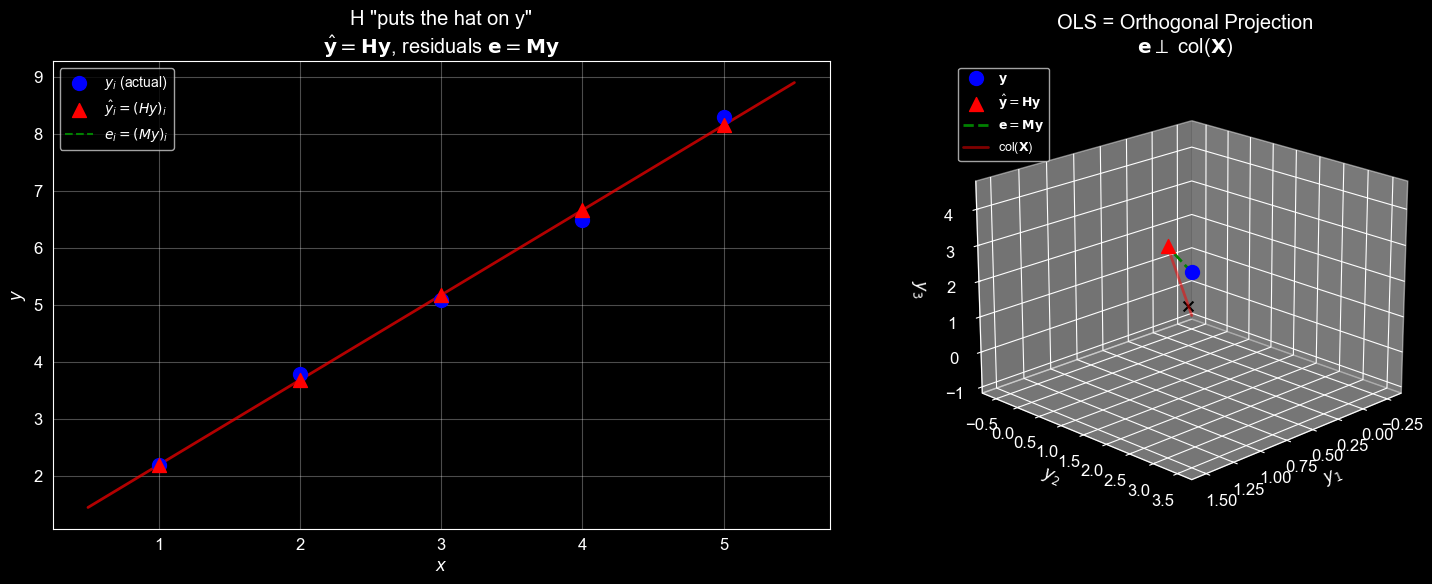

e · ŷ = 0.000000 (should be 0)
e · x = 0.000000 (should be 0)
✓ H projects y onto col(X), residuals are orthogonal


In [16]:
# === VISUALISE: Hat Matrix Projection (2D/3D) ===

fig = plt.figure(figsize=(16, 6))

# --- Panel 1: 2D Projection visualisation ---
ax = fig.add_subplot(121)

# Simple 2D example: X has 1 column (plus intercept would be 2D column space)
# For visual clarity, use n=3 data points, p=2 (intercept + slope)
# col(X) is a 2D subspace of R^3
# Let's show projection in R^2 for simplicity
np.random.seed(42)
x_2d = np.array([1, 2, 3, 4, 5])
y_2d = np.array([2.2, 3.8, 5.1, 6.5, 8.3])
X_2d = np.column_stack([np.ones(5), x_2d])

H_2d = X_2d @ np.linalg.inv(X_2d.T @ X_2d) @ X_2d.T
y_hat_2d = H_2d @ y_2d
e_2d = y_2d - y_hat_2d

ax.scatter(x_2d, y_2d, s=100, c='blue', zorder=5, label='$y_i$ (actual)')
ax.scatter(x_2d, y_hat_2d, s=100, c='red', marker='^', zorder=5, label='$\\hat{y}_i = (Hy)_i$')
for i in range(len(x_2d)):
    ax.plot([x_2d[i], x_2d[i]], [y_2d[i], y_hat_2d[i]], 'g--', lw=1.5, alpha=0.7)
    if i == 0:
        ax.plot([], [], 'g--', label='$e_i = (My)_i$')

beta_2d = np.linalg.inv(X_2d.T @ X_2d) @ X_2d.T @ y_2d
x_line = np.linspace(0.5, 5.5, 100)
ax.plot(x_line, beta_2d[0] + beta_2d[1] * x_line, 'r-', lw=2, alpha=0.7)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('H "puts the hat on y"\n$\\hat{\\mathbf{y}} = \\mathbf{H}\\mathbf{y}$, residuals $\\mathbf{e} = \\mathbf{M}\\mathbf{y}$')
ax.legend(fontsize=10)

# --- Panel 2: 3D Projection (n=3 example) ---
ax3 = fig.add_subplot(122, projection='3d')

# n=3 data points, p=1 (just intercept-free slope, so col(X) is a line in R^3)
x_3d = np.array([1, 2, 3]).reshape(-1, 1)  # X is 3×1
y_3d = np.array([1.5, 3.5, 4.0])

H_3d = x_3d @ np.linalg.inv(x_3d.T @ x_3d) @ x_3d.T
y_hat_3d = H_3d @ y_3d
e_3d = y_3d - y_hat_3d

# Plot y, y_hat, and residual
ax3.scatter(*y_3d, s=100, c='blue', label='$\\mathbf{y}$')
ax3.scatter(*y_hat_3d, s=100, c='red', marker='^', label='$\\hat{\\mathbf{y}} = \\mathbf{H}\\mathbf{y}$')
ax3.plot([y_3d[0], y_hat_3d[0]], [y_3d[1], y_hat_3d[1]], [y_3d[2], y_hat_3d[2]],
         'g--', lw=2, label='$\\mathbf{e} = \\mathbf{M}\\mathbf{y}$')

# Column space of X (a line through origin)
t = np.linspace(-1, 5, 50)
col_space = np.outer(x_3d.flatten() / np.linalg.norm(x_3d), t)
ax3.plot(col_space[0], col_space[1], col_space[2], 'r-', lw=2, alpha=0.5, label='col($\\mathbf{X}$)')

# Origin
ax3.scatter(0, 0, 0, s=50, c='black', marker='x')

ax3.set_xlabel('$y_1$'); ax3.set_ylabel('$y_2$'); ax3.set_zlabel('$y_3$')
ax3.set_title('OLS = Orthogonal Projection\n$\\mathbf{e} \\perp$ col($\\mathbf{X}$)')
ax3.legend(fontsize=9, loc='upper left')
ax3.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('hat_matrix_projection.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify orthogonality in 3D example
print(f"e · ŷ = {e_3d @ y_hat_3d:.6f} (should be 0)")
print(f"e · x = {e_3d @ x_3d.flatten():.6f} (should be 0)")
print("✓ H projects y onto col(X), residuals are orthogonal")


---
## 12. The Jacobian Matrix

### Definition

For a vector-valued function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the **Jacobian** is:

$$\mathbf{J} = \frac{\partial \mathbf{f}}{\partial \mathbf{x}} = \begin{pmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \end{pmatrix} \in \mathbb{R}^{m \times n}$$

### Best Linear Approximation

The Jacobian gives the **best linear approximation** to $\mathbf{f}$ near a point:

$$\mathbf{f}(\mathbf{x} + \boldsymbol{\delta}) \approx \mathbf{f}(\mathbf{x}) + \mathbf{J}\boldsymbol{\delta}$$

This is the multi-dimensional Taylor expansion to first order.

### Chain Rule via Jacobian

If $\mathbf{z} = \mathbf{g}(\mathbf{y})$ and $\mathbf{y} = \mathbf{f}(\mathbf{x})$, then:

$$\frac{\partial \mathbf{z}}{\partial \mathbf{x}} = \frac{\partial \mathbf{z}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \mathbf{J}_g \cdot \mathbf{J}_f$$

The chain rule becomes **matrix multiplication of Jacobians**. This is the mathematical foundation of **backpropagation**.

> 💡 **Physicist's Intuition:** The Jacobian appears in coordinate transformations. When changing from Cartesian $(x,y,z)$ to spherical $(r,\theta,\phi)$, the volume element transforms as $dV = |J| \, dr\,d\theta\,d\phi$ where $|J| = r^2\sin\theta$. The same $|J|$ appears in change-of-variables for probability densities: $p(y) = p(x) |J_{x \to y}|^{-1}$.


In [17]:
# === JACOBIAN: Computation and Verification ===

def numerical_jacobian(f, x, eps=1e-7):
    '''Compute Jacobian of vector function f at x using finite differences.'''
    f0 = f(x)
    m = len(f0)
    n = len(x)
    J = np.zeros((m, n))
    for j in range(n):
        x_plus = x.copy(); x_plus[j] += eps
        x_minus = x.copy(); x_minus[j] -= eps
        J[:, j] = (f(x_plus) - f(x_minus)) / (2 * eps)
    return J

# Example 1: Linear function f(x) = Ax
A = np.array([[2, 1, -1],
              [0, 3,  2]])  # 2×3 matrix
x = np.array([1.0, 2.0, 3.0])

f_linear = lambda x: A @ x
J_analytical = A  # Jacobian of Ax is A (numerator layout)
J_numerical = numerical_jacobian(f_linear, x)

print("=== Jacobian of f(x) = Ax ===")
print(f"  A (analytical Jacobian):")
print(f"  {A}")
print(f"  Numerical Jacobian:")
print(f"  {J_numerical.round(6)}")
print(f"  Match: {np.allclose(J_analytical, J_numerical)}")

# Example 2: Nonlinear function
f_nonlin = lambda x: np.array([x[0]**2 + x[1], x[0]*x[1]**2, np.sin(x[0]) + x[2]**3])
x = np.array([1.0, 2.0, 0.5])

# Analytical Jacobian
J_analytical_nl = np.array([
    [2*x[0], 1, 0],
    [x[1]**2, 2*x[0]*x[1], 0],
    [np.cos(x[0]), 0, 3*x[2]**2]
])
J_numerical_nl = numerical_jacobian(f_nonlin, x)

print(f"\n=== Jacobian of nonlinear f ===")
print(f"  f(x) = [x₁²+x₂, x₁x₂², sin(x₁)+x₃³]")
print(f"  Analytical J:")
print(f"  {J_analytical_nl.round(6)}")
print(f"  Numerical J:")
print(f"  {J_numerical_nl.round(6)}")
print(f"  Match: {np.allclose(J_analytical_nl, J_numerical_nl, atol=1e-5)}")

# Example 3: Chain rule — Jacobian multiplication
f = lambda x: np.array([x[0]*x[1], x[0]+x[1]**2])  # R^2 -> R^2
g = lambda y: np.array([y[0]**2, y[0]*y[1], y[1]])   # R^2 -> R^3

x0 = np.array([2.0, 3.0])
y0 = f(x0)

J_f = numerical_jacobian(f, x0)
J_g = numerical_jacobian(g, y0)

# Composite: h(x) = g(f(x))
h = lambda x: g(f(x))
J_h_direct = numerical_jacobian(h, x0)
J_h_chain = J_g @ J_f

print(f"\n=== Chain Rule: J_h = J_g · J_f ===")
print(f"  J_f ({J_f.shape}):\n{J_f.round(6)}")
print(f"  J_g ({J_g.shape}):\n{J_g.round(6)}")
print(f"  J_g · J_f ({J_h_chain.shape}):\n{J_h_chain.round(6)}")
print(f"  Direct J_h:\n{J_h_direct.round(6)}")
print(f"  Chain rule works: {np.allclose(J_h_chain, J_h_direct, atol=1e-4)}")


=== Jacobian of f(x) = Ax ===
  A (analytical Jacobian):
  [[ 2  1 -1]
 [ 0  3  2]]
  Numerical Jacobian:
  [[ 2.  1. -1.]
 [ 0.  3.  2.]]
  Match: True

=== Jacobian of nonlinear f ===
  f(x) = [x₁²+x₂, x₁x₂², sin(x₁)+x₃³]
  Analytical J:
  [[2.       1.       0.      ]
 [4.       4.       0.      ]
 [0.540302 0.       0.75    ]]
  Numerical J:
  [[2.       1.       0.      ]
 [4.       4.       0.      ]
 [0.540302 0.       0.75    ]]
  Match: True

=== Chain Rule: J_h = J_g · J_f ===
  J_f ((2, 2)):
[[3. 2.]
 [1. 6.]]
  J_g ((3, 2)):
[[12.  0.]
 [11.  6.]
 [ 0.  1.]]
  J_g · J_f ((3, 2)):
[[36. 24.]
 [39. 58.]
 [ 1.  6.]]
  Direct J_h:
[[36. 24.]
 [39. 58.]
 [ 1.  6.]]
  Chain rule works: True


---
## 13. The Hessian Matrix — Curvature of the Loss Landscape

### Definition

For $f: \mathbb{R}^n \to \mathbb{R}$, the **Hessian** is the matrix of second derivatives:

$$\mathbf{H}_f = \begin{pmatrix} \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots \\ \frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots \\ \vdots & & \ddots \end{pmatrix}$$

By Schwarz's theorem (for smooth $f$): $\frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial^2 f}{\partial x_j \partial x_i}$, so **the Hessian is symmetric**.

### Curvature and Critical Points

At a critical point ($\nabla f = \mathbf{0}$), the Hessian determines the nature:

| Eigenvalues of $\mathbf{H}$ | Type | Example |
|------------------------------|------|---------|
| All $> 0$ (PD) | Local minimum | Bottom of a bowl |
| All $< 0$ (ND) | Local maximum | Top of a hill |
| Mixed signs | Saddle point | Mountain pass |

### Second-Order Taylor Expansion

$$f(\mathbf{x} + \boldsymbol{\delta}) \approx f(\mathbf{x}) + \nabla f^T \boldsymbol{\delta} + \frac{1}{2}\boldsymbol{\delta}^T \mathbf{H}_f \boldsymbol{\delta}$$

### OLS Hessian

For $L(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$:

$$\mathbf{H}_L = 2\mathbf{X}^T\mathbf{X}$$

This is **constant** — doesn't depend on $\boldsymbol{\beta}$! The OLS loss landscape is a perfect paraboloid (quadratic bowl). No local minima, no saddle points — just one global minimum.

### Newton's Method

Uses the Hessian to take "perfect" steps:

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \mathbf{H}_f^{-1} \nabla f(\mathbf{x}_k)$$

For quadratic functions (like OLS), Newton's method converges in **one step**.

> 💡 **Physicist's Intuition:** The Hessian is the curvature tensor of the loss landscape. Positive eigenvalues = "potential well" (stable equilibrium). In GR, the Riemann curvature tensor $R^\mu_{\ \nu\rho\sigma}$ plays an analogous role for spacetime curvature. The Hessian is the "flat space" version — all the curvature information in a symmetric matrix.


In [18]:
# === HESSIAN: Curvature and Newton's Method ===

def numerical_hessian(f, x, eps=1e-5):
    '''Compute Hessian of scalar function f at x.'''
    n = len(x)
    H = np.zeros((n, n))
    f0 = f(x)
    for i in range(n):
        for j in range(i, n):
            x_pp = x.copy(); x_pp[i] += eps; x_pp[j] += eps
            x_pm = x.copy(); x_pm[i] += eps; x_pm[j] -= eps
            x_mp = x.copy(); x_mp[i] -= eps; x_mp[j] += eps
            x_mm = x.copy(); x_mm[i] -= eps; x_mm[j] -= eps
            H[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * eps**2)
            H[j, i] = H[i, j]
    return H

# Example 1: f(x,y) = x² + 3y² + xy (convex quadratic)
f1 = lambda x: x[0]**2 + 3*x[1]**2 + x[0]*x[1]
x0 = np.array([2.0, 1.0])

grad1 = numerical_gradient(f1, x0)
H1_analytical = np.array([[2, 1], [1, 6]])
H1_numerical = numerical_hessian(f1, x0)

print("=== Hessian of f(x,y) = x² + 3y² + xy ===")
print(f"  Analytical H: \n{H1_analytical}")
print(f"  Numerical H:  \n{H1_numerical.round(4)}")
evals_H1 = np.linalg.eigvalsh(H1_analytical)
print(f"  Eigenvalues: {evals_H1.round(4)} → PD → minimum exists")

# Newton's method: one step to minimum
x_newton = x0 - np.linalg.inv(H1_analytical) @ grad1
print(f"\n  x₀ = {x0}")
print(f"  ∇f(x₀) = {grad1.round(6)}")
print(f"  Newton step: x₁ = x₀ - H⁻¹∇f = {x_newton.round(6)}")
print(f"  ∇f(x₁) = {numerical_gradient(f1, x_newton).round(10)} (≈ 0, converged in 1 step!)")

# Example 2: Saddle point — f(x,y) = x² - y²
f2 = lambda x: x[0]**2 - x[1]**2
H2 = numerical_hessian(f2, np.array([0.0, 0.0]))
print(f"\n=== f(x,y) = x² - y² (saddle point at origin) ===")
print(f"  H = \n{H2.round(4)}")
print(f"  Eigenvalues: {np.linalg.eigvalsh(H2).round(4)} → indefinite → saddle point")

# Example 3: OLS Hessian = 2X'X (constant!)
print(f"\n=== OLS Hessian = 2X'X ===")
# Use small example
X_ex = np.column_stack([np.ones(5), np.array([1,2,3,4,5])])
y_ex = np.array([2.1, 4.0, 5.8, 8.1, 9.9])

L_ols = lambda beta: np.sum((y_ex - X_ex @ beta)**2)
H_ols_analytical = 2 * X_ex.T @ X_ex
H_ols_numerical = numerical_hessian(L_ols, np.array([1.0, 1.0]))

print(f"  Analytical 2X'X:\n{H_ols_analytical}")
print(f"  Numerical H:\n{H_ols_numerical.round(4)}")
print(f"  Match: {np.allclose(H_ols_analytical, H_ols_numerical, atol=0.01)}")
print(f"  Eigenvalues of 2X'X: {np.linalg.eigvalsh(H_ols_analytical).round(4)}")
print(f"  PD → unique minimum ✓")


=== Hessian of f(x,y) = x² + 3y² + xy ===
  Analytical H: 
[[2 1]
 [1 6]]
  Numerical H:  
[[2. 1.]
 [1. 6.]]
  Eigenvalues: [1.7639 6.2361] → PD → minimum exists

  x₀ = [2. 1.]
  ∇f(x₀) = [5. 8.]
  Newton step: x₁ = x₀ - H⁻¹∇f = [ 0. -0.]
  ∇f(x₁) = [ 3.7e-09 -4.7e-09] (≈ 0, converged in 1 step!)

=== f(x,y) = x² - y² (saddle point at origin) ===
  H = 
[[ 2.  0.]
 [ 0. -2.]]
  Eigenvalues: [-2.  2.] → indefinite → saddle point

=== OLS Hessian = 2X'X ===
  Analytical 2X'X:
[[ 10.  30.]
 [ 30. 110.]]
  Numerical H:
[[ 10.      30.    ]
 [ 30.     109.9999]]
  Match: True
  Eigenvalues of 2X'X: [  1.6905 118.3095]
  PD → unique minimum ✓


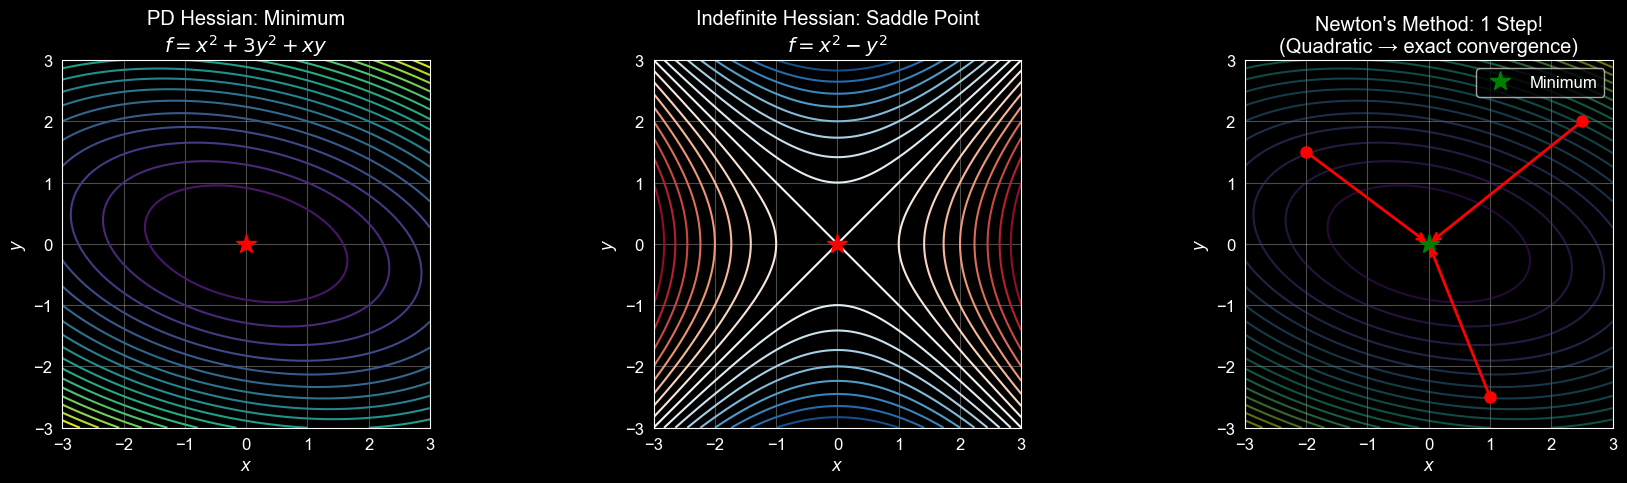

✓ Hessian determines curvature: PD → bowl, indefinite → saddle


In [19]:
# === VISUALISE: Loss Landscape Curvature ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Shared grid
xx = np.linspace(-3, 3, 200)
yy = np.linspace(-3, 3, 200)
XX, YY = np.meshgrid(xx, yy)

# --- Panel 1: Bowl (PD Hessian → minimum) ---
ax = axes[0]
ZZ = XX**2 + 3*YY**2 + XX*YY
cs = ax.contour(XX, YY, ZZ, levels=20, cmap='viridis')
ax.plot(0, 0, 'r*', markersize=15)
ax.set_title('PD Hessian: Minimum\n$f = x^2 + 3y^2 + xy$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_aspect('equal')

# --- Panel 2: Saddle (indefinite Hessian) ---
ax = axes[1]
ZZ = XX**2 - YY**2
cs = ax.contour(XX, YY, ZZ, levels=20, cmap='RdBu_r')
ax.plot(0, 0, 'r*', markersize=15)
ax.set_title('Indefinite Hessian: Saddle Point\n$f = x^2 - y^2$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_aspect('equal')

# --- Panel 3: Newton's method on quadratic ---
ax = axes[2]
ZZ = XX**2 + 3*YY**2 + XX*YY
ax.contour(XX, YY, ZZ, levels=20, cmap='viridis', alpha=0.5)

# Newton path from multiple starting points
H_inv = np.linalg.inv(np.array([[2, 1], [1, 6]]))
starts = [np.array([2.5, 2.0]), np.array([-2, 1.5]), np.array([1, -2.5])]
for x_start in starts:
    grad = np.array([2*x_start[0] + x_start[1], 6*x_start[1] + x_start[0]])
    x_end = x_start - H_inv @ grad
    ax.annotate('', xy=x_end, xytext=x_start,
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.plot(*x_start, 'ro', markersize=8)

ax.plot(0, 0, 'g*', markersize=15, label='Minimum')
ax.set_title("Newton's Method: 1 Step!\n(Quadratic → exact convergence)")
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.savefig('hessian_curvature.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Hessian determines curvature: PD → bowl, indefinite → saddle")


---
## 14. Chain Rule in Matrix Calculus

### Vector Chain Rule

For $\mathbf{z} = \mathbf{g}(\mathbf{y})$ and $\mathbf{y} = \mathbf{f}(\mathbf{x})$:

$$\frac{\partial \mathbf{z}}{\partial \mathbf{x}} = \frac{\partial \mathbf{z}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}}$$

Jacobians multiply: $\mathbf{J}_{h} = \mathbf{J}_g \cdot \mathbf{J}_f$ where $h = g \circ f$.

For a scalar loss $L$ at the end of a chain:

$$\frac{\partial L}{\partial \mathbf{x}} = \frac{\partial L}{\partial \mathbf{z}} \cdot \frac{\partial \mathbf{z}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}}$$

### Connection to Backpropagation

A neural network is a **composition of functions**:

$$\text{Layer 1: } \mathbf{h}_1 = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)$$
$$\text{Layer 2: } \hat{\mathbf{y}} = \mathbf{W}_2 \mathbf{h}_1 + \mathbf{b}_2$$
$$\text{Loss: } L = \|\mathbf{y} - \hat{\mathbf{y}}\|^2$$

Backpropagation computes:
$$\frac{\partial L}{\partial \mathbf{W}_1} = \frac{\partial L}{\partial \hat{\mathbf{y}}} \cdot \frac{\partial \hat{\mathbf{y}}}{\partial \mathbf{h}_1} \cdot \frac{\partial \mathbf{h}_1}{\partial \mathbf{W}_1}$$

Each factor is a Jacobian. **Backprop IS the chain rule applied layer by layer from output to input.**

> 💡 **Physicist's Intuition:** This is exactly like propagating uncertainties in a measurement chain. If $T = f(P)$ and $P = g(V)$, then $\frac{dT}{dV} = \frac{dT}{dP} \cdot \frac{dP}{dV}$. Backprop just does this for vector-valued functions using Jacobian matrices instead of scalar derivatives.

> ⚠️ **Common Misconception:** Backprop is NOT a special algorithm unique to neural networks. It is literally the chain rule of calculus applied to computational graphs. Any differentiable computation can be "backpropagated."


In [20]:
# === CHAIN RULE: Two-Layer Network Example ===

np.random.seed(42)

# Simple 2-layer network: input(3) → hidden(4) → output(2)
d_in, d_hidden, d_out = 3, 4, 2
W1 = np.random.randn(d_hidden, d_in) * 0.5
b1 = np.zeros(d_hidden)
W2 = np.random.randn(d_out, d_hidden) * 0.5
b2 = np.zeros(d_out)

# Activation function
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# Forward pass
x = np.array([1.0, 2.0, 3.0])
y_true = np.array([1.0, 0.0])

z1 = W1 @ x + b1           # pre-activation
h1 = relu(z1)               # hidden layer output
z2 = W2 @ h1 + b2           # output
y_pred = z2                  # linear output
loss = np.sum((y_true - y_pred)**2)

print("=== Forward Pass ===")
print(f"  x:     {x}")
print(f"  z1:    {z1.round(4)}")
print(f"  h1:    {h1.round(4)}")
print(f"  ŷ:     {y_pred.round(4)}")
print(f"  Loss:  {loss:.4f}")

# === BACKWARD PASS (Chain Rule) ===
# ∂L/∂ŷ
dL_dy = -2 * (y_true - y_pred)  # (2,)

# ∂L/∂W2: ŷ = W2·h1 + b2, so ∂ŷ/∂W2 gives ∂L/∂W2 = dL_dy ⊗ h1
dL_dW2 = np.outer(dL_dy, h1)    # (2, 4)

# ∂L/∂h1: chain through W2
dL_dh1 = W2.T @ dL_dy           # (4,)

# ∂L/∂z1: chain through ReLU
dL_dz1 = dL_dh1 * relu_derivative(z1)  # element-wise (4,)

# ∂L/∂W1: z1 = W1·x + b1
dL_dW1 = np.outer(dL_dz1, x)    # (4, 3)

print(f"\n=== Backward Pass (Chain Rule) ===")
print(f"  ∂L/∂ŷ:  {dL_dy.round(4)}")
print(f"  ∂L/∂W2 shape: {dL_dW2.shape}")
print(f"  ∂L/∂h1: {dL_dh1.round(4)}")
print(f"  ∂L/∂W1 shape: {dL_dW1.shape}")

# === VERIFY with numerical gradient ===
def network_loss(W1_flat):
    W1_mat = W1_flat.reshape(d_hidden, d_in)
    h = relu(W1_mat @ x + b1)
    y_p = W2 @ h + b2
    return np.sum((y_true - y_p)**2)

dL_dW1_numerical = numerical_gradient(network_loss, W1.flatten()).reshape(d_hidden, d_in)

print(f"\n=== Verify: Analytical vs Numerical Gradient for W1 ===")
print(f"  Max absolute difference: {np.max(np.abs(dL_dW1 - dL_dW1_numerical)):.2e}")
print(f"  Match: {np.allclose(dL_dW1, dL_dW1_numerical, atol=1e-5)}")
print("✓ Backpropagation IS the chain rule!")


=== Forward Pass ===
  x:     [1. 2. 3.]
  z1:    [ 1.0816  0.1762  0.8528 -0.8907]
  h1:    [1.0816 0.1762 0.8528 0.    ]
  ŷ:     [-0.7732 -0.9073]
  Loss:  3.9673

=== Backward Pass (Chain Rule) ===
  ∂L/∂ŷ:  [-3.5464 -1.8145]
  ∂L/∂W2 shape: (2, 4)
  ∂L/∂h1: [0.4899 3.1075 3.8824 2.2784]
  ∂L/∂W1 shape: (4, 3)

=== Verify: Analytical vs Numerical Gradient for W1 ===
  Max absolute difference: 4.25e-09
  Match: True
✓ Backpropagation IS the chain rule!


---
## 15. Multiple Linear Regression — All Features at Once

### Design Matrix with All Features

$$\mathbf{X} = \begin{pmatrix} 1 & x_{1,\text{MedInc}} & x_{1,\text{HouseAge}} & \cdots & x_{1,\text{Longitude}} \\ \vdots & & & & \vdots \\ 1 & x_{n,\text{MedInc}} & x_{n,\text{HouseAge}} & \cdots & x_{n,\text{Longitude}} \end{pmatrix} \in \mathbb{R}^{20640 \times 9}$$

### Interpretation of $\hat{\beta}_j$

Each $\hat{\beta}_j$ is a **partial regression coefficient**: the expected change in $y$ for a one-unit increase in $x_j$, **holding all other features constant**.

This is NOT the same as the simple regression coefficient! Adding more features changes the slopes.

### Multicollinearity

When features are highly correlated, $\mathbf{X}^T\mathbf{X}$ becomes **ill-conditioned** (nearly singular):
- $\hat{\boldsymbol{\beta}}$ becomes unstable (small data changes → large coefficient changes)
- Standard errors inflate
- Individual coefficients become uninterpretable

**Variance Inflation Factor (VIF):** $\text{VIF}_j = \frac{1}{1 - R_j^2}$ where $R_j^2$ is the $R^2$ from regressing $x_j$ on all other features. VIF $> 10$ indicates serious multicollinearity.

> ⚠️ **Common Misconception:** Multicollinearity does NOT affect predictions — $\hat{\mathbf{y}}$ is still the best linear unbiased estimate. It only makes individual $\hat{\beta}_j$ unreliable. If you care about prediction only, multicollinearity may not matter. If you care about interpreting coefficients, it's a serious problem.


In [21]:
# === MULTIPLE LINEAR REGRESSION: Full Housing Model ===

# Design matrix with intercept
n = X_raw.shape[0]
X_full = np.column_stack([np.ones(n), X_raw.values])
y = y_raw.copy()
p = X_full.shape[1]
feature_names = ['intercept'] + list(X_raw.columns)

# OLS: β̂ = (X'X)⁻¹X'y
XtX = X_full.T @ X_full
XtX_inv = np.linalg.inv(XtX)
beta_full = XtX_inv @ X_full.T @ y

# Predictions and R²
y_hat = X_full @ beta_full
e = y - y_hat
SS_res = e @ e
SS_tot = np.sum((y - y.mean())**2)
R2 = 1 - SS_res / SS_tot
R2_adj = 1 - (SS_res / (n - p)) / (SS_tot / (n - 1))

print("=== Multiple Linear Regression: All 8 Features ===")
print(f"{'Feature':>12s}  {'Coefficient':>12s}")
print("-" * 28)
for name, coef in zip(feature_names, beta_full):
    print(f"  {name:>12s}: {coef:12.6f}")
print(f"\n  R² = {R2:.4f}")
print(f"  Adjusted R² = {R2_adj:.4f}")
print(f"  n = {n}, p = {p}")

# Compare with sklearn
lr_sk = LinearRegression().fit(X_raw.values, y)
beta_sk = np.concatenate([[lr_sk.intercept_], lr_sk.coef_])
print(f"\n  Matches sklearn? {np.allclose(beta_full, beta_sk, atol=1e-6)}")

# VIF computation
print(f"\n=== Variance Inflation Factors ===")
from numpy.linalg import inv
X_features = X_raw.values
for j, name in enumerate(X_raw.columns):
    # Regress x_j on all other features
    others = np.delete(X_features, j, axis=1)
    others_with_intercept = np.column_stack([np.ones(n), others])
    beta_j = np.linalg.lstsq(others_with_intercept, X_features[:, j], rcond=None)[0]
    y_hat_j = others_with_intercept @ beta_j
    SS_res_j = np.sum((X_features[:, j] - y_hat_j)**2)
    SS_tot_j = np.sum((X_features[:, j] - X_features[:, j].mean())**2)
    R2_j = 1 - SS_res_j / SS_tot_j
    VIF_j = 1 / (1 - R2_j) if R2_j < 1 else np.inf
    flag = " ⚠️" if VIF_j > 10 else ""
    print(f"  {name:>12s}: VIF = {VIF_j:8.2f}{flag}")


=== Multiple Linear Regression: All 8 Features ===
     Feature   Coefficient
----------------------------
     intercept:   -36.941920
        MedInc:     0.436693
      HouseAge:     0.009436
      AveRooms:    -0.107322
     AveBedrms:     0.645066
    Population:    -0.000004
      AveOccup:    -0.003787
      Latitude:    -0.421314
     Longitude:    -0.434514

  R² = 0.6062
  Adjusted R² = 0.6061
  n = 20640, p = 9

  Matches sklearn? True

=== Variance Inflation Factors ===
        MedInc: VIF =     2.50
      HouseAge: VIF =     1.24
      AveRooms: VIF =     8.34
     AveBedrms: VIF =     6.99
    Population: VIF =     1.14
      AveOccup: VIF =     1.01
      Latitude: VIF =     9.30
     Longitude: VIF =     8.96


---
## 16. Covariance Matrix of $\hat{\boldsymbol{\beta}}$

### Derivation

Starting from $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$, and noting that $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}) = \boldsymbol{\beta} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\boldsymbol{\varepsilon}$$

So $\hat{\boldsymbol{\beta}} - \boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\boldsymbol{\varepsilon}$, and:

$$\text{Var}(\hat{\boldsymbol{\beta}}) = E[(\hat{\boldsymbol{\beta}} - \boldsymbol{\beta})(\hat{\boldsymbol{\beta}} - \boldsymbol{\beta})^T]$$

$$= (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \underbrace{E[\boldsymbol{\varepsilon}\boldsymbol{\varepsilon}^T]}_{\sigma^2 \mathbf{I}} \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}$$

$$= \sigma^2 (\mathbf{X}^T\mathbf{X})^{-1}\underbrace{\mathbf{X}^T\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}}_{\mathbf{I}}$$

$$\boxed{\text{Var}(\hat{\boldsymbol{\beta}}) = \sigma^2 (\mathbf{X}^T\mathbf{X})^{-1}}$$

### Practical Quantities

- **Standard errors:** $\text{SE}(\hat{\beta}_j) = \sqrt{s^2 [(\mathbf{X}^T\mathbf{X})^{-1}]_{jj}}$
- **Estimated variance:** $s^2 = \frac{\mathbf{e}^T\mathbf{e}}{n - p}$ (unbiased estimator of $\sigma^2$)
- **t-statistics:** $t_j = \hat{\beta}_j / \text{SE}(\hat{\beta}_j)$

> 💡 **Physicist's Intuition:** $\sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$ is the "error ellipsoid" in parameter space. When features are orthogonal ($\mathbf{X}^T\mathbf{X}$ is diagonal), parameter uncertainties are independent. Correlated features create tilted ellipsoids — like coupled oscillators where knowing one displacement constrains the other.


In [22]:
# === COVARIANCE MATRIX OF β̂ ===

# Residual variance estimate
s2 = (e @ e) / (n - p)
print(f"=== Variance Estimation ===")
print(f"  s² = e'e/(n-p) = {e@e:.4f}/{n-p} = {s2:.6f}")
print(f"  s (RMSE) = {np.sqrt(s2):.6f}")

# Covariance matrix of β̂
Var_beta = s2 * XtX_inv
SE_beta = np.sqrt(np.diag(Var_beta))

print(f"\n=== Standard Errors and t-statistics ===")
print(f"{'Feature':>12s}  {'β̂':>10s}  {'SE':>10s}  {'t-stat':>10s}")
print("-" * 50)
for name, coef, se in zip(feature_names, beta_full, SE_beta):
    t_stat = coef / se if se > 0 else np.inf
    sig = "***" if abs(t_stat) > 3.29 else "**" if abs(t_stat) > 2.58 else "*" if abs(t_stat) > 1.96 else ""
    print(f"  {name:>12s}: {coef:10.4f}  {se:10.4f}  {t_stat:10.2f} {sig}")

# Compare with statsmodels
try:
    import statsmodels.api as sm
    X_sm = sm.add_constant(X_raw.values)
    model = sm.OLS(y, X_sm).fit()
    
    print(f"\n=== Verify with statsmodels ===")
    print(f"  SE match? {np.allclose(SE_beta, model.bse, atol=1e-4)}")
    print(f"  R² match? {np.allclose(R2, model.rsquared, atol=1e-6)}")
    print(f"\n  statsmodels summary (partial):")
    print(f"  {'Feature':>12s}  {'Our SE':>10s}  {'SM SE':>10s}")
    for name, se_ours, se_sm in zip(feature_names, SE_beta, model.bse):
        print(f"  {name:>12s}: {se_ours:10.6f}  {se_sm:10.6f}")
except ImportError:
    print("\n  (statsmodels not installed — skipping verification)")


=== Variance Estimation ===
  s² = e'e/(n-p) = 10821.9852/20631 = 0.524550
  s (RMSE) = 0.724258

=== Standard Errors and t-statistics ===
     Feature          β̂          SE      t-stat
--------------------------------------------------
     intercept:   -36.9419      0.6589      -56.07 ***
        MedInc:     0.4367      0.0042      104.05 ***
      HouseAge:     0.0094      0.0004       21.14 ***
      AveRooms:    -0.1073      0.0059      -18.24 ***
     AveBedrms:     0.6451      0.0281       22.93 ***
    Population:    -0.0000      0.0000       -0.84 
      AveOccup:    -0.0038      0.0005       -7.77 ***
      Latitude:    -0.4213      0.0072      -58.54 ***
     Longitude:    -0.4345      0.0075      -57.68 ***

=== Verify with statsmodels ===
  SE match? True
  R² match? True

  statsmodels summary (partial):
       Feature      Our SE       SM SE
     intercept:   0.658894    0.658894
        MedInc:   0.004197    0.004197
      HouseAge:   0.000446    0.000446
      AveRoo

---
## 17. Regularisation in Matrix Form

### Why Regularise?

When $\mathbf{X}^T\mathbf{X}$ is ill-conditioned (near-singular), the OLS solution $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ is **unstable**. Regularisation fixes this by adding a penalty.

### Ridge Regression ($L^2$ penalty)

$$L_{\text{Ridge}}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|^2$$

Setting $\nabla L = 0$:

$$-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} + 2\lambda\boldsymbol{\beta} = 0$$

$$\boxed{\hat{\boldsymbol{\beta}}_{\text{Ridge}} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}}$$

**Key insight:** $\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I}$ is **always invertible** for $\lambda > 0$ (all eigenvalues shifted by $\lambda$).

**Bayesian interpretation:** Ridge = OLS with a **Gaussian prior** on $\boldsymbol{\beta}$: $\boldsymbol{\beta} \sim \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$ where $\lambda = \sigma^2/\tau^2$.

### LASSO ($L^1$ penalty)

$$L_{\text{LASSO}}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|_1$$

- **No closed-form solution** (the $L^1$ norm is not differentiable at 0)
- Solved iteratively (coordinate descent, ISTA/FISTA)
- **Produces sparse solutions**: some $\hat{\beta}_j = 0$ exactly (automatic feature selection)
- **Bayesian interpretation:** Laplace prior $p(\beta_j) \propto e^{-|\beta_j|/b}$

Geometrically: the $L^1$ ball has **corners** on the axes. The loss contours are more likely to intersect these corners, setting coefficients to exactly zero.

### Elastic Net

Combines $L^1$ and $L^2$:

$$L_{\text{EN}} = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda_1\|\boldsymbol{\beta}\|_1 + \lambda_2\|\boldsymbol{\beta}\|^2$$

> 💡 **Physicist's Intuition:** Ridge is like adding a **restoring force** (harmonic potential $\frac{1}{2}k x^2$) that pulls coefficients toward zero. LASSO is like **friction** (constant force opposing motion) that can bring coefficients to a complete stop. Ridge shrinks but never eliminates; LASSO shrinks and prunes.


In [23]:
# === REGULARISATION: Ridge and LASSO on Housing ===

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Standardise features (important for regularisation!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.values)
y = y_raw.copy()

# Ridge: β̂ = (X'X + λI)⁻¹X'y
lambdas = np.logspace(-2, 4, 50)
ridge_coefs = []
lasso_coefs = []

for lam in lambdas:
    # Ridge — manual formula
    XtX = X_scaled.T @ X_scaled
    Xty = X_scaled.T @ y
    beta_ridge = np.linalg.inv(XtX + lam * np.eye(X_scaled.shape[1])) @ Xty
    ridge_coefs.append(beta_ridge)
    
    # LASSO — sklearn (no closed form)
    lasso = Lasso(alpha=lam / (2 * n), max_iter=10000)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# Verify Ridge formula matches sklearn
ridge_sk = Ridge(alpha=10.0).fit(X_scaled, y)
XtX = X_scaled.T @ X_scaled
beta_ridge_manual = np.linalg.inv(XtX + 10.0 * np.eye(X_scaled.shape[1])) @ X_scaled.T @ y
print("=== Ridge Verification ===")
print(f"  Manual (X'X+λI)⁻¹X'y matches sklearn? {np.allclose(beta_ridge_manual, ridge_sk.coef_, atol=1e-4)}")

# Condition number improvement
print(f"\n=== Condition Number ===")
print(f"  cond(X'X) = {np.linalg.cond(XtX):.2f}")
for lam in [0.01, 1, 100]:
    print(f"  cond(X'X + {lam}I) = {np.linalg.cond(XtX + lam*np.eye(8)):.2f}")


=== Ridge Verification ===
  Manual (X'X+λI)⁻¹X'y matches sklearn? True

=== Condition Number ===
  cond(X'X) = 44.47
  cond(X'X + 0.01I) = 44.46
  cond(X'X + 1I) = 44.42
  cond(X'X + 100I) = 40.29


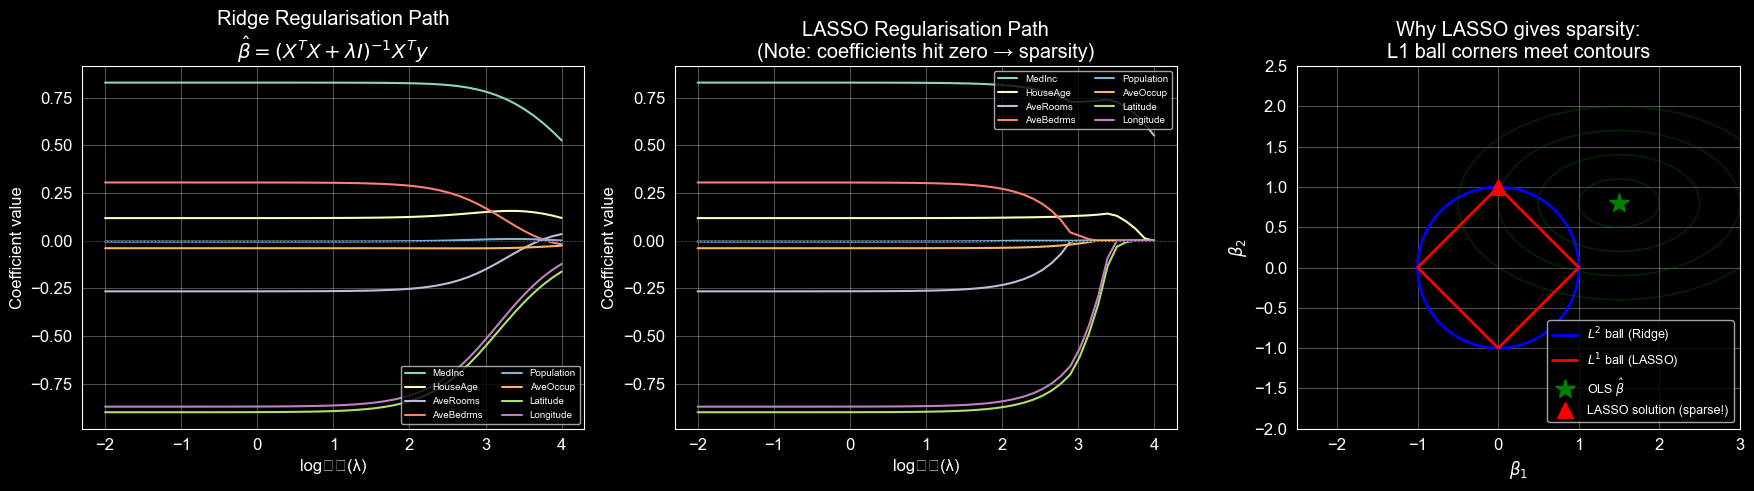

✓ Ridge shrinks all coefficients; LASSO shrinks AND zeros some out


In [24]:
# === VISUALISE: Regularisation Paths ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Ridge path ---
ax = axes[0]
for j, name in enumerate(X_raw.columns):
    ax.plot(np.log10(lambdas), ridge_coefs[:, j], lw=1.5, label=name)
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('Coefficient value')
ax.set_title('Ridge Regularisation Path\n$\\hat{\\beta} = (X^TX + \\lambda I)^{-1}X^Ty$')
ax.legend(fontsize=7, ncol=2)
ax.axhline(y=0, color='k', lw=0.5, ls='--')

# --- Panel 2: LASSO path ---
ax = axes[1]
for j, name in enumerate(X_raw.columns):
    ax.plot(np.log10(lambdas), lasso_coefs[:, j], lw=1.5, label=name)
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('Coefficient value')
ax.set_title('LASSO Regularisation Path\n(Note: coefficients hit zero → sparsity)')
ax.legend(fontsize=7, ncol=2)
ax.axhline(y=0, color='k', lw=0.5, ls='--')

# --- Panel 3: L1 vs L2 ball geometry ---
ax = axes[2]
theta = np.linspace(0, 2*np.pi, 500)

# L2 ball
ax.plot(np.cos(theta), np.sin(theta), 'b-', lw=2, label='$L^2$ ball (Ridge)')
# L1 ball
l1_pts = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
ax.plot(l1_pts[:,0], l1_pts[:,1], 'r-', lw=2, label='$L^1$ ball (LASSO)')

# Loss contour ellipse (centered at OLS solution)
beta_ols = np.array([1.5, 0.8])
for level in [0.5, 1.0, 1.5, 2.0]:
    ell_x = beta_ols[0] + level * np.cos(theta)
    ell_y = beta_ols[1] + level * 0.6 * np.sin(theta)
    ax.plot(ell_x, ell_y, 'g-', alpha=0.3, lw=1)

ax.plot(*beta_ols, 'g*', markersize=15, label='OLS $\\hat{\\beta}$')
ax.plot(0, 1, 'r^', markersize=12, label='LASSO solution (sparse!)')
ax.set_xlim(-2.5, 3); ax.set_ylim(-2, 2.5)
ax.set_aspect('equal')
ax.set_xlabel('$\\beta_1$'); ax.set_ylabel('$\\beta_2$')
ax.set_title('Why LASSO gives sparsity:\nL1 ball corners meet contours')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('regularisation_paths.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Ridge shrinks all coefficients; LASSO shrinks AND zeros some out")


---
## 18. Tensors — Beyond Matrices

### The Hierarchy

| Rank | Object | Example | Indices |
|------|--------|---------|---------|
| 0 | Scalar | Temperature $T$ | None |
| 1 | Vector | Velocity $v^i$ | 1 index |
| 2 | Matrix | Stress $\sigma^{ij}$, metric $g_{\mu\nu}$ | 2 indices |
| 3 | 3-tensor | Christoffel $\Gamma^\mu_{\nu\rho}$ | 3 indices |
| 4 | 4-tensor | Riemann $R^\mu_{\ \nu\rho\sigma}$ | 4 indices |

### Index Notation and Einstein Convention

**Einstein summation convention:** repeated indices (one up, one down) are summed over:

$$a_i b^i \equiv \sum_i a_i b^i \quad \text{(dot product)}$$

$$A^i_{\ j} x^j \equiv \sum_j A^i_{\ j} x^j \quad \text{(matrix-vector)}$$

$$A^i_{\ k} B^k_{\ j} \equiv \sum_k A^i_{\ k} B^k_{\ j} \quad \text{(matrix-matrix)}$$

### NumPy's `einsum`

NumPy's `np.einsum` implements Einstein notation directly:

```python
np.einsum('i,i->', a, b)     # dot product: aᵢbᵢ
np.einsum('ij,j->i', A, x)   # matrix-vector: Aᵢⱼxⱼ
np.einsum('ik,kj->ij', A, B) # matrix-matrix: AᵢₖBₖⱼ
np.einsum('ij,kj->ik', A, B) # ABᵀ
np.einsum('ii->', A)          # trace: Aᵢᵢ
```

### Covariant vs Contravariant (Brief)

In physics, the distinction matters when the metric isn't the identity:

- **Contravariant** $v^\mu$ (tangent vector): transforms as $v'^\mu = \frac{\partial x'^\mu}{\partial x^\nu} v^\nu$
- **Covariant** $v_\mu$ (covector): transforms as $v'_\mu = \frac{\partial x^\nu}{\partial x'^\mu} v_\nu$
- Metric raises/lowers: $v_\mu = g_{\mu\nu} v^\nu$

In flat Euclidean space (ML), $g_{\mu\nu} = \delta_{\mu\nu}$, so the distinction vanishes. But in information geometry (Fisher information metric), it returns!

> 💡 **Physicist's Intuition:** In GR, you MUST keep track of index positions because spacetime is curved. In ML, the "curvature" appears when you use the Fisher Information Matrix as a metric on parameter space — this is **natural gradient descent**, which uses $\mathbf{F}^{-1}\nabla L$ instead of $\nabla L$ (compare with Newton's method using $\mathbf{H}^{-1}\nabla L$).


In [25]:
# === TENSORS AND EINSUM ===

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
x = np.array([1, 2])
y = np.array([3, 4])

print("=== Einstein Summation with np.einsum ===\n")

# Dot product: aᵢbᵢ
dot = np.einsum('i,i->', x, y)
print(f"  Dot product:    einsum('i,i->', x, y) = {dot}   [np.dot: {np.dot(x,y)}]")

# Outer product: aᵢbⱼ
outer = np.einsum('i,j->ij', x, y)
print(f"  Outer product:  einsum('i,j->ij', x, y) =\n{outer}")
print(f"  [np.outer: \n{np.outer(x,y)}]")

# Matrix-vector: Aᵢⱼxⱼ
mv = np.einsum('ij,j->i', A, x)
print(f"\n  Matrix-vector:  einsum('ij,j->i', A, x) = {mv}   [A@x: {A@x}]")

# Matrix-matrix: AᵢₖBₖⱼ
mm = np.einsum('ik,kj->ij', A, B)
print(f"  Matrix-matrix:  einsum('ik,kj->ij', A, B) =\n{mm}")
print(f"  [A@B:\n{A@B}]")

# ABᵀ: AᵢₖBⱼₖ
abt = np.einsum('ik,jk->ij', A, B)
print(f"\n  ABᵀ:           einsum('ik,jk->ij', A, B) =\n{abt}")
print(f"  [A@B.T:\n{A@B.T}]")

# Trace: Aᵢᵢ
tr = np.einsum('ii->', A)
print(f"\n  Trace:          einsum('ii->', A) = {tr}   [np.trace: {np.trace(A)}]")

# Quadratic form: xᵢAᵢⱼxⱼ
qf = np.einsum('i,ij,j->', x, A, x)
print(f"  Quadratic form: einsum('i,ij,j->', x, A, x) = {qf}   [x@A@x: {x@A@x}]")

# 3-tensor example: batch matrix multiplication
print(f"\n=== 3-Tensor: Batch Operations ===")
batch_A = np.random.randn(5, 3, 4)  # 5 matrices of size 3×4
batch_B = np.random.randn(5, 4, 2)  # 5 matrices of size 4×2

# Batch matrix multiply: Cₙᵢⱼ = Aₙᵢₖ Bₙₖⱼ
batch_C = np.einsum('nik,nkj->nij', batch_A, batch_B)
print(f"  batch_A shape: {batch_A.shape}")
print(f"  batch_B shape: {batch_B.shape}")
print(f"  batch_C shape: {batch_C.shape}")
print(f"  Matches loop: {np.allclose(batch_C, np.array([a@b for a,b in zip(batch_A, batch_B)]))}")


=== Einstein Summation with np.einsum ===

  Dot product:    einsum('i,i->', x, y) = 11   [np.dot: 11]
  Outer product:  einsum('i,j->ij', x, y) =
[[3 4]
 [6 8]]
  [np.outer: 
[[3 4]
 [6 8]]]

  Matrix-vector:  einsum('ij,j->i', A, x) = [ 5 11]   [A@x: [ 5 11]]
  Matrix-matrix:  einsum('ik,kj->ij', A, B) =
[[19 22]
 [43 50]]
  [A@B:
[[19 22]
 [43 50]]]

  ABᵀ:           einsum('ik,jk->ij', A, B) =
[[17 23]
 [39 53]]
  [A@B.T:
[[17 23]
 [39 53]]]

  Trace:          einsum('ii->', A) = 5   [np.trace: 5]
  Quadratic form: einsum('i,ij,j->', x, A, x) = 27   [x@A@x: 27]

=== 3-Tensor: Batch Operations ===
  batch_A shape: (5, 3, 4)
  batch_B shape: (5, 4, 2)
  batch_C shape: (5, 3, 2)
  Matches loop: True


---
## 19. Tensor Calculus Basics

### Derivatives Produce Higher-Rank Tensors

| Input | Output | Derivative | Rank |
|-------|--------|-----------|------|
| Scalar $f$ | — | Gradient $\partial f / \partial \mathbf{x}$ | Vector (rank 1) |
| Vector $\mathbf{f}$ | — | Jacobian $\partial \mathbf{f} / \partial \mathbf{x}$ | Matrix (rank 2) |
| Matrix $\mathbf{F}$ | — | $\partial \mathbf{F} / \partial \mathbf{x}$ | 3-tensor (rank 3) |
| Scalar $f$ | — | Hessian $\partial^2 f / \partial \mathbf{x}^2$ | Matrix (rank 2) |

### Key Identities for Scalar-by-Matrix Derivatives

$$\frac{\partial}{\partial \mathbf{A}} \text{tr}(\mathbf{A}\mathbf{B}) = \mathbf{B}^T$$

$$\frac{\partial}{\partial \mathbf{A}} \text{tr}(\mathbf{A}^T\mathbf{B}) = \mathbf{B}$$

$$\frac{\partial}{\partial \mathbf{A}}(\mathbf{x}^T\mathbf{A}\mathbf{x}) = \mathbf{x}\mathbf{x}^T$$

These are crucial for deriving gradients in neural networks (weight matrices).

### Connection to Neural Network Gradients

In a neural network layer $\mathbf{h} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$:

The gradient $\frac{\partial L}{\partial \mathbf{W}}$ is a matrix with the same shape as $\mathbf{W}$. This is a scalar-by-matrix derivative — technically involving a 2-tensor.

> ⚠️ **Common Misconception:** "Tensors in deep learning" (as in TensorFlow/PyTorch) are just multi-dimensional arrays. True tensors have specific transformation rules under coordinate changes. A 3D array of pixel values is NOT a tensor in the physics sense, even though the framework calls it one.


In [26]:
# === TENSOR CALCULUS: Verify Identities ===

def numerical_matrix_gradient(f, A, eps=1e-7):
    '''Gradient of scalar function f with respect to matrix A.'''
    grad = np.zeros_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            A_plus = A.copy(); A_plus[i, j] += eps
            A_minus = A.copy(); A_minus[i, j] -= eps
            grad[i, j] = (f(A_plus) - f(A_minus)) / (2 * eps)
    return grad

A = np.array([[1.0, 2.0], [3.0, 4.0]])
B = np.array([[5.0, 6.0], [7.0, 8.0]])
x = np.array([1.0, 2.0])

# Identity 1: ∂tr(AB)/∂A = B'
print("=== ∂tr(AB)/∂A = Bᵀ ===")
f1 = lambda A: np.trace(A @ B)
grad1 = numerical_matrix_gradient(f1, A)
print(f"  Analytical (Bᵀ):\n{B.T}")
print(f"  Numerical:\n{grad1.round(6)}")
print(f"  Match: {np.allclose(B.T, grad1)}")

# Identity 2: ∂tr(A'B)/∂A = B
print(f"\n=== ∂tr(AᵀB)/∂A = B ===")
f2 = lambda A: np.trace(A.T @ B)
grad2 = numerical_matrix_gradient(f2, A)
print(f"  Analytical (B):\n{B}")
print(f"  Numerical:\n{grad2.round(6)}")
print(f"  Match: {np.allclose(B, grad2)}")

# Identity 3: ∂(x'Ax)/∂A = xx'
print(f"\n=== ∂(xᵀAx)/∂A = xxᵀ ===")
f3 = lambda A: x @ A @ x
grad3 = numerical_matrix_gradient(f3, A)
xxT = np.outer(x, x)
print(f"  Analytical (xxᵀ):\n{xxT}")
print(f"  Numerical:\n{grad3.round(6)}")
print(f"  Match: {np.allclose(xxT, grad3)}")

# Higher-order: ∂(vector)/∂(vector) = Jacobian (matrix)
print(f"\n=== Derivative Rank Hierarchy ===")
print(f"  ∂(scalar)/∂(vector) → vector (gradient):     rank 1")
print(f"  ∂(vector)/∂(vector) → matrix (Jacobian):     rank 2")
print(f"  ∂(scalar)/∂(matrix) → matrix:                rank 2")
print(f"  ∂(matrix)/∂(scalar) → matrix:                rank 2")
print(f"  ∂(matrix)/∂(vector) → 3-tensor:              rank 3")
print(f"  ∂²(scalar)/∂(vector)² → matrix (Hessian):    rank 2")


=== ∂tr(AB)/∂A = Bᵀ ===
  Analytical (Bᵀ):
[[5. 7.]
 [6. 8.]]
  Numerical:
[[5. 7.]
 [6. 8.]]
  Match: True

=== ∂tr(AᵀB)/∂A = B ===
  Analytical (B):
[[5. 6.]
 [7. 8.]]
  Numerical:
[[5. 6.]
 [7. 8.]]
  Match: True

=== ∂(xᵀAx)/∂A = xxᵀ ===
  Analytical (xxᵀ):
[[1. 2.]
 [2. 4.]]
  Numerical:
[[1. 2.]
 [2. 4.]]
  Match: True

=== Derivative Rank Hierarchy ===
  ∂(scalar)/∂(vector) → vector (gradient):     rank 1
  ∂(vector)/∂(vector) → matrix (Jacobian):     rank 2
  ∂(scalar)/∂(matrix) → matrix:                rank 2
  ∂(matrix)/∂(scalar) → matrix:                rank 2
  ∂(matrix)/∂(vector) → 3-tensor:              rank 3
  ∂²(scalar)/∂(vector)² → matrix (Hessian):    rank 2


---
## 20. SVD and Pseudoinverse

### Singular Value Decomposition

**Every** matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ (not just square!) has an SVD:

$$\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$$

where:
- $\mathbf{U} \in \mathbb{R}^{m \times m}$: orthogonal, columns = **left singular vectors**
- $\boldsymbol{\Sigma} \in \mathbb{R}^{m \times n}$: diagonal, entries = **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $\mathbf{V} \in \mathbb{R}^{n \times n}$: orthogonal, columns = **right singular vectors**

### Connection to Eigendecomposition

$$\mathbf{A}^T\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^T\boldsymbol{\Sigma}\mathbf{V}^T = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^T$$

So the right singular vectors of $\mathbf{A}$ are eigenvectors of $\mathbf{A}^T\mathbf{A}$, and $\sigma_i^2$ are eigenvalues of $\mathbf{A}^T\mathbf{A}$.

### The Moore-Penrose Pseudoinverse

$$\mathbf{A}^+ = \mathbf{V}\boldsymbol{\Sigma}^+\mathbf{U}^T$$

where $\boldsymbol{\Sigma}^+$ inverts non-zero singular values: $\sigma_i^+ = 1/\sigma_i$ if $\sigma_i \neq 0$, else $0$.

For full-rank $\mathbf{X}$: $\mathbf{X}^+ = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$, so:

$$\hat{\boldsymbol{\beta}} = \mathbf{X}^+ \mathbf{y}$$

### Truncated SVD

Keep only the $k$ largest singular values → dimensionality reduction (related to PCA):

$$\mathbf{A}_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

This is the **best rank-$k$ approximation** to $\mathbf{A}$ (Eckart–Young theorem).

> 💡 **Physicist's Intuition:** SVD decomposes a linear transformation into rotate ($\mathbf{V}^T$) → stretch ($\boldsymbol{\Sigma}$) → rotate ($\mathbf{U}$). It's the most general decomposition of any linear map, like decomposing any Lorentz transformation into boosts and rotations. The condition number $\kappa = \sigma_{\max}/\sigma_{\min}$ measures how "distorted" the transformation is.


In [27]:
# === SVD: Decompose the Design Matrix ===

# Use standardised design matrix (without intercept for clean SVD)
X_svd = StandardScaler().fit_transform(X_raw.values)
n_obs, n_feat = X_svd.shape

U, sigma, Vt = np.linalg.svd(X_svd, full_matrices=False)
V = Vt.T

print("=== SVD of Standardised Design Matrix ===")
print(f"  X shape: {X_svd.shape}")
print(f"  U shape: {U.shape}, Σ shape: ({len(sigma)},), Vᵀ shape: {Vt.shape}")
print(f"\n  Singular values:")
for i, s in enumerate(sigma):
    print(f"    σ_{i+1} = {s:.4f}  (σ² = {s**2:.4f})")

# Verify A'A = VΣ²V'
AtA = X_svd.T @ X_svd
AtA_svd = V @ np.diag(sigma**2) @ V.T
print(f"\n  X'X = VΣ²Vᵀ? {np.allclose(AtA, AtA_svd)}")

# Eigenvalues of X'X = σ²
eig_AtA = np.sort(np.linalg.eigvalsh(AtA))[::-1]
print(f"  Eigenvalues of X'X: {eig_AtA.round(2)}")
print(f"  σ² values:          {(sigma**2).round(2)}")
print(f"  Match: {np.allclose(eig_AtA, sigma**2)}")

# Condition number
kappa = sigma.max() / sigma.min()
print(f"\n  Condition number κ = σ_max/σ_min = {kappa:.2f}")
print(f"  (κ > 30 suggests multicollinearity issues)")


=== SVD of Standardised Design Matrix ===
  X shape: (20640, 8)
  U shape: (20640, 8), Σ shape: (8,), Vᵀ shape: (8, 8)

  Singular values:
    σ_1 = 204.5391  (σ² = 41836.2361)
    σ_2 = 197.0534  (σ² = 38830.0235)
    σ_3 = 161.9732  (σ² = 26235.3134)
    σ_4 = 145.8788  (σ² = 21280.6177)
    σ_5 = 143.8856  (σ² = 20703.0676)
    σ_6 = 116.6602  (σ² = 13609.6038)
    σ_7 = 41.0397  (σ² = 1684.2608)
    σ_8 = 30.6737  (σ² = 940.8770)

  X'X = VΣ²Vᵀ? True
  Eigenvalues of X'X: [41836.24 38830.02 26235.31 21280.62 20703.07 13609.6   1684.26   940.88]
  σ² values:          [41836.24 38830.02 26235.31 21280.62 20703.07 13609.6   1684.26   940.88]
  Match: True

  Condition number κ = σ_max/σ_min = 6.67
  (κ > 30 suggests multicollinearity issues)


In [28]:
# === OLS VIA PSEUDOINVERSE AND SVD ===

y = y_raw.copy()

# Method 1: (X'X)⁻¹X'y (only works with intercept column)
X_with_int = np.column_stack([np.ones(n_obs), X_svd])
beta_normal = np.linalg.inv(X_with_int.T @ X_with_int) @ X_with_int.T @ y

# Method 2: Pseudoinverse X⁺y
X_pinv = np.linalg.pinv(X_with_int)
beta_pinv = X_pinv @ y

# Method 3: SVD-based (manual pseudoinverse)
U_full, sigma_full, Vt_full = np.linalg.svd(X_with_int, full_matrices=False)
sigma_inv = np.where(sigma_full > 1e-10, 1.0 / sigma_full, 0)
beta_svd = Vt_full.T @ np.diag(sigma_inv) @ U_full.T @ y

# Method 4: lstsq (uses SVD internally)
beta_lstsq = np.linalg.lstsq(X_with_int, y, rcond=None)[0]

print("=== OLS via Different Methods ===")
print(f"  Normal equations: {beta_normal[:3].round(6)}...")
print(f"  Pseudoinverse:    {beta_pinv[:3].round(6)}...")
print(f"  Manual SVD:       {beta_svd[:3].round(6)}...")
print(f"  lstsq:            {beta_lstsq[:3].round(6)}...")
print(f"\n  All match? {np.allclose(beta_normal, beta_pinv, atol=1e-6) and np.allclose(beta_normal, beta_svd, atol=1e-6)}")

# Truncated SVD regression
print(f"\n=== Truncated SVD Regression ===")
for k in [2, 4, 6, 8]:
    sigma_trunc = sigma_inv.copy()
    sigma_trunc[k+1:] = 0  # zero out small singular values (+1 for intercept)
    beta_trunc = Vt_full.T @ np.diag(sigma_trunc) @ U_full.T @ y
    y_hat_trunc = X_with_int @ beta_trunc
    R2_trunc = 1 - np.sum((y - y_hat_trunc)**2) / np.sum((y - y.mean())**2)
    print(f"  k={k} components: R² = {R2_trunc:.4f}")


=== OLS via Different Methods ===
  Normal equations: [2.068558 0.829619 0.118752]...
  Pseudoinverse:    [2.068558 0.829619 0.118752]...
  Manual SVD:       [2.068558 0.829619 0.118752]...
  lstsq:            [2.068558 0.829619 0.118752]...

  All match? True

=== Truncated SVD Regression ===
  k=2 components: R² = -3.1845
  k=4 components: R² = -2.7589
  k=6 components: R² = 0.5053
  k=8 components: R² = 0.6062


---
## 21. Geometric View of Regression — Putting It All Together

### The Big Picture

OLS regression is an **orthogonal projection** of $\mathbf{y}$ onto the column space of $\mathbf{X}$.

$$\text{col}(\mathbf{X}) = \{\mathbf{X}\boldsymbol{\beta} : \boldsymbol{\beta} \in \mathbb{R}^p\}$$

This is a $p$-dimensional subspace of $\mathbb{R}^n$. The predicted values $\hat{\mathbf{y}}$ are the point in col($\mathbf{X}$) closest to $\mathbf{y}$.

### The Decomposition

$$\mathbf{y} = \underbrace{\hat{\mathbf{y}}}_{\in \text{col}(\mathbf{X})} + \underbrace{\mathbf{e}}_{\perp \text{col}(\mathbf{X})}$$

This is the fundamental decomposition. It gives us:

### Pythagoras in $\mathbb{R}^n$

Since $\hat{\mathbf{y}} \perp \mathbf{e}$:

$$\|\mathbf{y}\|^2 = \|\hat{\mathbf{y}}\|^2 + \|\mathbf{e}\|^2$$

After centring (subtracting means):

$$\underbrace{\sum(y_i - \bar{y})^2}_{SS_{\text{total}}} = \underbrace{\sum(\hat{y}_i - \bar{y})^2}_{SS_{\text{regression}}} + \underbrace{\sum(y_i - \hat{y}_i)^2}_{SS_{\text{residual}}}$$

### R² as Cosine Squared

$$R^2 = \frac{SS_{\text{reg}}}{SS_{\text{tot}}} = \cos^2\theta$$

where $\theta$ is the angle between $\mathbf{y}$ (centred) and $\hat{\mathbf{y}}$ (centred) in $\mathbb{R}^n$.

- $R^2 = 1$: $\theta = 0$, $\mathbf{y}$ lies in col($\mathbf{X}$) — perfect fit
- $R^2 = 0$: $\theta = 90°$, $\mathbf{y} \perp$ col($\mathbf{X}$) — model explains nothing

> 💡 **Physicist's Intuition:** This is identical to decomposing a force into components along and perpendicular to a surface. $SS_{\text{reg}}$ is the "explained" component (projection onto the model subspace), and $SS_{\text{res}}$ is the "unexplained" component (perpendicular to it). $R^2 = \cos^2\theta$ is literally the fraction of "energy" ($\|\mathbf{y}\|^2$) captured by the model.

> ⚠️ **Common Misconception:** R² always increases when you add more features (the column space gets larger, so the projection gets closer). This does NOT mean the model is better — it might be overfitting. Adjusted R² penalises for added features.


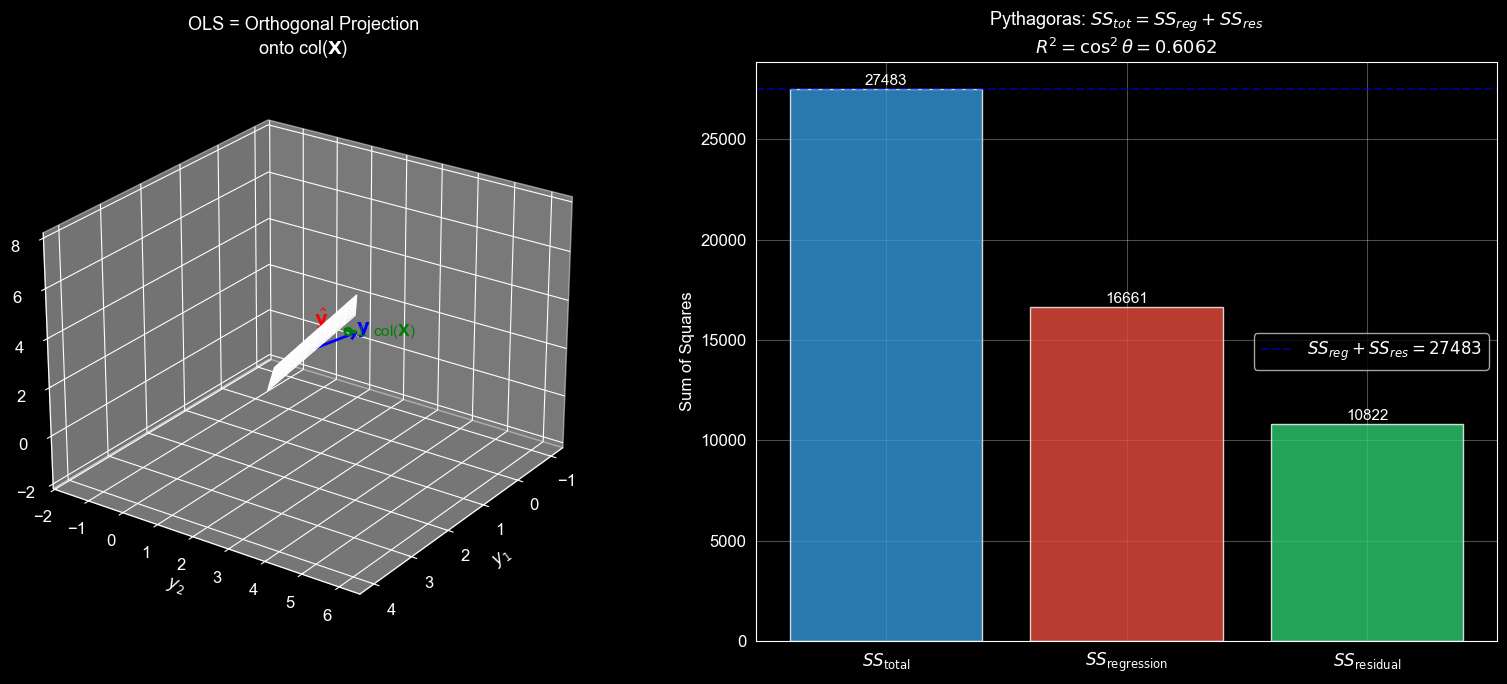

=== Pythagoras in Rⁿ ===
  ||y||²    = 30.5000
  ||ŷ||²    = 30.1250
  ||e||²    = 0.3750
  ||ŷ||²+||e||² = 30.5000
  Match ||y||²? True

=== Housing: Pythagoras Check ===
  SS_total       = 27483.20
  SS_reg + SS_res = 27483.20
  Match? True
  R² = cos²(θ) = 0.6062
  θ = 38.87° (angle between y and col(X))


In [29]:
# === GEOMETRIC VIEW: 3D Projection Visualisation ===

fig = plt.figure(figsize=(16, 7))

# --- Panel 1: 3D projection with n=3 observations ---
ax = fig.add_subplot(121, projection='3d')

# n=3, p=2 (intercept + 1 feature): col(X) is a 2D plane in R^3
np.random.seed(42)
x_feat = np.array([1.0, 2.0, 3.0])
X_geo = np.column_stack([np.ones(3), x_feat])  # 3×2
y_geo = np.array([1.5, 3.5, 4.0])

# Project y onto col(X)
H_geo = X_geo @ np.linalg.inv(X_geo.T @ X_geo) @ X_geo.T
y_hat_geo = H_geo @ y_geo
e_geo = y_geo - y_hat_geo

# Create plane (col(X) = span of two columns)
col1 = X_geo[:, 0]; col2 = X_geo[:, 1]
s_range = np.linspace(-0.5, 2, 10)
t_range = np.linspace(-0.5, 2, 10)
SS, TT = np.meshgrid(s_range, t_range)
plane_pts = np.array([SS * col1[i] + TT * col2[i] for i in range(3)])

ax.plot_surface(plane_pts[0], plane_pts[1], plane_pts[2], alpha=0.2, color='lightblue')

# y vector
ax.quiver(0, 0, 0, y_geo[0], y_geo[1], y_geo[2], color='blue', arrow_length_ratio=0.1, lw=2)
ax.text(y_geo[0]+0.1, y_geo[1]+0.1, y_geo[2]+0.1, '$\\mathbf{y}$', fontsize=14, color='blue')

# y_hat vector
ax.quiver(0, 0, 0, y_hat_geo[0], y_hat_geo[1], y_hat_geo[2], color='red', arrow_length_ratio=0.1, lw=2)
ax.text(y_hat_geo[0]+0.1, y_hat_geo[1]-0.3, y_hat_geo[2], '$\\hat{\\mathbf{y}}$', fontsize=14, color='red')

# Residual (perpendicular line)
ax.plot([y_geo[0], y_hat_geo[0]], [y_geo[1], y_hat_geo[1]], [y_geo[2], y_hat_geo[2]],
        'g--', lw=2.5)
mid = (y_geo + y_hat_geo) / 2
ax.text(mid[0]+0.2, mid[1]+0.2, mid[2], '$\\mathbf{e} \\perp$ col($\\mathbf{X}$)', fontsize=11, color='green')

ax.set_xlabel('$y_1$'); ax.set_ylabel('$y_2$'); ax.set_zlabel('$y_3$')
ax.set_title('OLS = Orthogonal Projection\nonto col($\\mathbf{X}$)', fontsize=13)
ax.view_init(elev=25, azim=35)

# Verify Pythagoras
norm_y_sq = np.linalg.norm(y_geo)**2
norm_yhat_sq = np.linalg.norm(y_hat_geo)**2
norm_e_sq = np.linalg.norm(e_geo)**2

# --- Panel 2: SS decomposition ---
ax2 = fig.add_subplot(122)

# Use actual Housing data
X_full = np.column_stack([np.ones(len(y_raw)), X_raw.values])
beta_final = np.linalg.lstsq(X_full, y_raw, rcond=None)[0]
y_hat_full = X_full @ beta_final
e_full = y_raw - y_hat_full

y_bar = y_raw.mean()
SS_tot = np.sum((y_raw - y_bar)**2)
SS_reg = np.sum((y_hat_full - y_bar)**2)
SS_res = np.sum(e_full**2)
R2_final = 1 - SS_res / SS_tot

# Pythagoras check
bars = ax2.bar(['$SS_{\\mathrm{total}}$', '$SS_{\\mathrm{regression}}$', '$SS_{\\mathrm{residual}}$'],
               [SS_tot, SS_reg, SS_res], color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
ax2.set_ylabel('Sum of Squares')
ax2.set_title(f'Pythagoras: $SS_{{tot}} = SS_{{reg}} + SS_{{res}}$\n'
              f'$R^2 = \\cos^2\\theta = {R2_final:.4f}$', fontsize=13)

# Add values on bars
for bar, val in zip(bars, [SS_tot, SS_reg, SS_res]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:.0f}', ha='center', fontsize=11)

# Verify Pythagoras
ax2.axhline(y=SS_reg + SS_res, color='blue', ls='--', alpha=0.5, 
            label=f'$SS_{{reg}}+SS_{{res}}={SS_reg+SS_res:.0f}$')
ax2.legend()

plt.tight_layout()
plt.savefig('geometric_regression.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"=== Pythagoras in Rⁿ ===")
print(f"  ||y||²    = {norm_y_sq:.4f}")
print(f"  ||ŷ||²    = {norm_yhat_sq:.4f}")
print(f"  ||e||²    = {norm_e_sq:.4f}")
print(f"  ||ŷ||²+||e||² = {norm_yhat_sq + norm_e_sq:.4f}")
print(f"  Match ||y||²? {np.allclose(norm_y_sq, norm_yhat_sq + norm_e_sq)}")

print(f"\n=== Housing: Pythagoras Check ===")
print(f"  SS_total       = {SS_tot:.2f}")
print(f"  SS_reg + SS_res = {SS_reg + SS_res:.2f}")
print(f"  Match? {np.allclose(SS_tot, SS_reg + SS_res)}")
print(f"  R² = cos²(θ) = {R2_final:.4f}")
theta_deg = np.degrees(np.arccos(np.sqrt(R2_final)))
print(f"  θ = {theta_deg:.2f}° (angle between y and col(X))")


In [30]:
# === FINAL SUMMARY: The Matrix View of Regression ===

summary_lines = [
    '=' * 70,
    '         THE MATRIX VIEW OF REGRESSION — SUMMARY',
    '=' * 70,
    '',
    '  Model:       y = Xb + e',
    "  Loss:        L = ||y - Xb||^2 = (y-Xb)'(y-Xb)",
    "  Gradient:    dL/db = -2X'y + 2X'Xb",
    "  Solution:    b_hat = (X'X)^-1 X'y         (Normal Equations)",
    "  Predictions: y_hat = Hy = X(X'X)^-1 X'y   (Hat Matrix)",
    '  Residuals:   e = My = (I-H)y               (Residual Maker)',
    '  Geometry:    y_hat = proj_{col(X)}(y),  e perp col(X)',
    '  Pythagoras:  ||y||^2 = ||y_hat||^2 + ||e||^2',
    '               => SS_tot = SS_reg + SS_res',
    "  Variance:    Var(b_hat) = s^2 (X'X)^-1",
    "  Ridge:       b_hat = (X'X + lambda*I)^-1 X'y  (Always invertible)",
    "  SVD:         b_hat = X+ y = V Sigma+ U' y     (Most general)",
    "  Hessian:     d^2L/db^2 = 2X'X                 (Constant!)",
    '',
    '  Key insight: OLS IS orthogonal projection.',
    '  Everything else follows from this one geometric fact.',
    '=' * 70,
]
print('\n'.join(summary_lines))

# R² summary across models
print("=== Model Comparison ===")
print(f"  Simple (MedInc only): R² = {1 - np.sum((y_raw - (beta0_hat + beta1_hat * X_raw['MedInc'].values))**2) / np.sum((y_raw - y_raw.mean())**2):.4f}")
print(f"  Multiple (all 8):     R² = {R2_final:.4f}")
print(f"  Ridge (λ=10):         R² = {1 - np.sum((y_raw - X_with_int @ np.linalg.inv(X_with_int.T @ X_with_int + 10*np.eye(X_with_int.shape[1])) @ X_with_int.T @ y_raw)**2) / np.sum((y_raw - y_raw.mean())**2):.4f}")


         THE MATRIX VIEW OF REGRESSION — SUMMARY

  Model:       y = Xb + e
  Loss:        L = ||y - Xb||^2 = (y-Xb)'(y-Xb)
  Gradient:    dL/db = -2X'y + 2X'Xb
  Solution:    b_hat = (X'X)^-1 X'y         (Normal Equations)
  Predictions: y_hat = Hy = X(X'X)^-1 X'y   (Hat Matrix)
  Residuals:   e = My = (I-H)y               (Residual Maker)
  Geometry:    y_hat = proj_{col(X)}(y),  e perp col(X)
  Pythagoras:  ||y||^2 = ||y_hat||^2 + ||e||^2
               => SS_tot = SS_reg + SS_res
  Variance:    Var(b_hat) = s^2 (X'X)^-1
  Ridge:       b_hat = (X'X + lambda*I)^-1 X'y  (Always invertible)
  SVD:         b_hat = X+ y = V Sigma+ U' y     (Most general)
  Hessian:     d^2L/db^2 = 2X'X                 (Constant!)

  Key insight: OLS IS orthogonal projection.
  Everything else follows from this one geometric fact.
=== Model Comparison ===
  Simple (MedInc only): R² = 0.4734
  Multiple (all 8):     R² = 0.6062
  Ridge (λ=10):         R² = 0.6062
